# BRSET Patient-Level Evaluation — Glaucoma Detection (increased_cup_disc)

This notebook performs **patient-level** glaucoma detection on **BRSET** using **MLP with Bayesian hyperparameter optimization**.

## Target
- **`increased_cup_disc`**: Binary indicator of increased cup-to-disc ratio (a glaucoma surrogate)
- BRSET: 16,266 images across 8,524 patients (~19.7% positive rate)

## Workflow
1. Load all BRSET embeddings (7 CSV files, one per foundation model)
2. Create a **single 80/20 patient-level train/test split** (reused for all embeddings)
3. Train **MLP with BayesSearchCV** — searches architectures, regularization, learning rate, batch size, **and positive-class weight**
4. Evaluate on **patient-level** (aggregate predictions per patient)
5. Generate classification reports, confusion matrices, ROC curves, training dynamics

**Note on mBRSET**: mBRSET does **not** contain `increased_cup_disc` — only DR-related labels (`final_icdr`, `final_edema`). Glaucoma evaluation is only possible on BRSET.

**Key design choices**:
- **No PCA** — raw embeddings (768 or 1024 dims) are used directly
- **Class weight search** — `pos_class_weight` (1.0–8.0) is part of the Bayesian search space to find optimal minority-class weighting per embedding
- **Pruned architecture options** (12 instead of 18) and reduced Bayesian iterations for faster training

## 1. Setup and Imports

In [2]:
import os
import copy
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    log_loss,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
)
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

import src.retina_evaluation as reval
from src.retina_benchmark import list_embeddings_csvs
from src.retina_embeddings_dataset import load_retina_embeddings_dataset

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.style.use("seaborn-v0_8-whitegrid")

print("Imports complete.")

Imports complete.


## 2. Configuration

In [3]:
# Paths and dataset
PROJECT_ROOT = Path.cwd()
DATASET_NAME = "brset"

# Split configuration
RANDOM_SEED = 42
TEST_FRAC = 0.2  # 80/20 split

# Task definitions — SINGLE BINARY TASK: Glaucoma
BINARY_TASKS = ["increased_cup_disc"]
BINARY_TASK_MAP = {
    "increased_cup_disc": "glaucoma_detection",
}

# Model hyperparameters
CPU_COUNT = os.cpu_count() or 1

# ─── BAYESIAN HYPERPARAMETER SEARCH CONFIGURATION ───
USE_BAYESIAN_SEARCH = True
N_BAYES_ITER = 25           # reduced from 30 for speed
BAYES_CV_FOLDS = 3
BAYES_N_JOBS = min(3, CPU_COUNT)  # parallel CV folds

# Define architecture options (pruned from 18 → 12 for speed)
ARCHITECTURE_OPTIONS = [
    (128,),
    (256,),
    (512,),
    (128, 128),
    (256, 256),
    (512, 256),
    (512, 512),
    (1024, 512),
    (128, 128, 128),
    (256, 256, 256),
    (512, 256, 128),
    (1024, 512, 256),
]

# Search space — includes pos_class_weight to find best minority weighting
from skopt.space import Integer, Real, Categorical
SEARCH_SPACE = {
    'hidden_layer_sizes': Integer(0, len(ARCHITECTURE_OPTIONS) - 1, name='hidden_layer_sizes'),
    'alpha': Real(1e-5, 1e-1, prior='log-uniform', name='alpha'),
    'learning_rate_init': Real(1e-4, 1e-3, prior='log-uniform', name='learning_rate_init'),
    'batch_size': Categorical([64, 128, 256], name='batch_size'),
    'pos_class_weight': Real(1.0, 8.0, prior='uniform', name='pos_class_weight'),
}

# Default threshold selection on internal validation set
THRESHOLD_METHOD = "f1"  # "youden" | "f1"
THRESHOLD_GRID_SIZE = 201

# ─── BASE MLP CONFIG (for non-search training & dynamics) ───
MLP_CONFIG_BINARY = {
    "hidden_layer_sizes": (512, 256),
    "alpha": 1e-2,
    "learning_rate_init": 0.0003,
    "batch_size": 128,
    "max_epochs": 250,       # reduced from 400
    "patience": 20,          # reduced from 30
    "min_delta": 1e-5,
    "warmup_epochs": 20,     # reduced from 30
}

# ─── PER-EMBEDDING OVERRIDES ───
EMBEDDING_OVERRIDES = {
    "dinov3_convnext_base": {},
    "dinov3_vitb16": {},
    "RETFound_mae_shanghai": {},
    "RETFound_mae_natureCFP": {},
    "RETFound_dinov2_shanghai": {},
    "vit_base": {},
    "convnextv2_base": {},
}


def resolve_config(emb_stem):
    """
    Merge base config with per-embedding overrides.
    Returns (config_dict, matched_pattern | None).
    """
    base = MLP_CONFIG_BINARY.copy()
    matched = None
    
    for pattern, overrides in EMBEDDING_OVERRIDES.items():
        if overrides:
            if pattern in emb_stem:
                base.update(overrides)
                matched = pattern
                break
    
    return base, matched


# Output configuration
RESULTS_DIR = PROJECT_ROOT / "results" / "brset_patient_eval_glaucoma"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
SAVE_PLOTS = True

print(f"Dataset: {DATASET_NAME}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Random seed: {RANDOM_SEED}")
print(f"Test fraction: {TEST_FRAC}")
print(f"Task: increased_cup_disc (glaucoma_detection)")
print(f"No PCA — raw embedding features used")
print(f"Bayesian Search: {USE_BAYESIAN_SEARCH} (iterations={N_BAYES_ITER}, cv_folds={BAYES_CV_FOLDS}, n_jobs={BAYES_N_JOBS})")
print(f"Architectures: {len(ARCHITECTURE_OPTIONS)} options")
print(f"Alpha search: 1e-5 to 1e-1 (log-uniform)")
print(f"Learning rate search: 1e-4 to 1e-3 (log-uniform)")
print(f"Batch sizes: [64, 128, 256]")
print(f"Positive class weight search: 1.0 to 8.0 (uniform)")
print(f"Max epochs: {MLP_CONFIG_BINARY['max_epochs']}, Patience: {MLP_CONFIG_BINARY['patience']}")
print(f"Threshold method: {THRESHOLD_METHOD} (grid={THRESHOLD_GRID_SIZE})")

Dataset: brset
Results directory: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_patient_eval_glaucoma
Random seed: 42
Test fraction: 0.2
Task: increased_cup_disc (glaucoma_detection)
No PCA — raw embedding features used
Bayesian Search: True (iterations=25, cv_folds=3, n_jobs=3)
Architectures: 12 options
Alpha search: 1e-5 to 1e-1 (log-uniform)
Learning rate search: 1e-4 to 1e-3 (log-uniform)
Batch sizes: [64, 128, 256]
Positive class weight search: 1.0 to 8.0 (uniform)
Max epochs: 250, Patience: 20
Threshold method: f1 (grid=201)


## 3. Load Embeddings and Create Patient-Level Split

In [4]:
# Get paths
embed_dir = PROJECT_ROOT / "data" / f"{DATASET_NAME}_embeddings"
labels_path = embed_dir / f"{DATASET_NAME}_labels" / f"labels_{DATASET_NAME}.csv"

# List all embedding files
embedding_files = list_embeddings_csvs(embed_dir)
if not embedding_files:
    raise FileNotFoundError(f"No embedding CSV files found under {embed_dir}")

print(f"Found {len(embedding_files)} embedding files:")
for i, emb in enumerate(embedding_files):
    print(f"  {i}: {emb.name}")

# Load first embedding to create the split
base_ds = load_retina_embeddings_dataset(
    dataset=DATASET_NAME,
    embeddings_csv_path=embedding_files[0],
    labels_csv_path=labels_path,
)

# Verify increased_cup_disc column exists
assert "increased_cup_disc" in base_ds.df.columns, "increased_cup_disc column not found in BRSET labels!"
cup_disc_counts = base_ds.df["increased_cup_disc"].value_counts(dropna=False)
print(f"\nincreased_cup_disc distribution:")
print(cup_disc_counts)
print(f"Positive rate: {cup_disc_counts.get(1, 0) / cup_disc_counts.sum():.1%}")

# Create patient-level split (stratified by increased_cup_disc)
split = reval.make_patient_split(
    df=base_ds.df,
    group_col="patient_id",
    label_col="increased_cup_disc",
    val_frac=TEST_FRAC,
    seed=RANDOM_SEED,
)

print(f"\nPatient split:")
print(f"  Train patients: {len(split.train_patient_ids)}")
print(f"  Test patients: {len(split.val_patient_ids)}")
print(f"  Total: {len(split.train_patient_ids) + len(split.val_patient_ids)}")

# Save split for reproducibility
split_info = pd.DataFrame({
    "patient_id": list(split.train_patient_ids) + list(split.val_patient_ids),
    "split": ["train"] * len(split.train_patient_ids) + ["test"] * len(split.val_patient_ids),
})
split_info.to_csv(RESULTS_DIR / "patient_split.csv", index=False)
print(f"Saved split to: {RESULTS_DIR / 'patient_split.csv'}")

Found 7 embedding files:
  0: Embeddings_brset_convnextv2_base_.csv
  1: Embeddings_brset_dinov3_convnext_base.csv
  2: Embeddings_brset_dinov3_vitb16.csv
  3: Embeddings_brset_RETFound_dinov2_shanghai.csv
  4: Embeddings_brset_RETFound_mae_natureCFP.csv
  5: Embeddings_brset_RETFound_mae_shanghai.csv
  6: Embeddings_brset_vit_base_.csv

increased_cup_disc distribution:
increased_cup_disc
0    13064
1     3202
Name: count, dtype: Int64
Positive rate: 19.7%

Patient split:
  Train patients: 6819
  Test patients: 1705
  Total: 8524
Saved split to: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_patient_eval_glaucoma\patient_split.csv


## 4. Helper Functions for Patient-Level Aggregation

In [5]:
from sklearn.utils.class_weight import compute_class_weight


def aggregate_patient_predictions(df, group_col="patient_id"):
    """
    Aggregate image-level predictions to patient-level by taking the majority vote
    for class labels and averaging probabilities.
    """
    patient_groups = []
    
    for patient_id, group in df.groupby(group_col):
        y_pred_patient = group["y_pred"].mode()[0] if len(group["y_pred"].mode()) > 0 else group["y_pred"].iloc[0]
        y_proba_patient = group["y_proba"].mean()
        y_true_patient = group["y_true"].mode()[0] if len(group["y_true"].mode()) > 0 else group["y_true"].iloc[0]
        
        patient_groups.append({
            "patient_id": patient_id,
            "y_true": y_true_patient,
            "y_pred": y_pred_patient,
            "y_proba": y_proba_patient,
            "n_images": len(group),
        })
    
    return pd.DataFrame(patient_groups)


def make_sample_weights(y, pos_class_weight=1.0):
    """
    Build per-sample weights: negative class gets 1.0, positive gets pos_class_weight.
    Weights are normalized so mean == 1.0.
    """
    y = np.asarray(y)
    w = np.where(y == 1, float(pos_class_weight), 1.0).astype(np.float32)
    mean_w = w.mean()
    if mean_w > 0:
        w /= mean_w
    return w


def find_optimal_threshold(y_true, y_proba, method="youden", grid_size=99):
    """
    Find optimal binary classification threshold using a validation set.
    """
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    if y_true.size == 0:
        return 0.5

    if method == "youden":
        fpr, tpr, thresholds = roc_curve(y_true, y_proba)
        j_scores = tpr - fpr
        best_idx = int(np.argmax(j_scores))
        return float(thresholds[best_idx])

    if method == "f1":
        from sklearn.metrics import f1_score
        grid_size = max(11, min(int(grid_size), 1001))
        thresholds = np.linspace(0.01, 0.99, grid_size)
        best_t, best_f1 = 0.5, -1.0
        for t in thresholds:
            y_pred = (y_proba >= t).astype(int)
            f1 = float(f1_score(y_true, y_pred, zero_division=0))
            if f1 > best_f1:
                best_f1 = f1
                best_t = float(t)
        return best_t

    raise ValueError(f"Unknown threshold method: {method}")


def weighted_log_loss(y_true, y_proba, labels, sample_weight=None):
    """Compute log loss with optional sample weights."""
    return log_loss(y_true, y_proba, labels=labels, sample_weight=sample_weight)


# ─── WRAPPER CLASS FOR BAYESIAN SEARCH (with pos_class_weight) ───
from sklearn.base import BaseEstimator, ClassifierMixin

class MLPWrapperForBayesSearch(BaseEstimator, ClassifierMixin):
    """
    Wrapper for MLPClassifier that:
    - Converts integer architecture indices to tuples
    - Applies per-sample class weights via pos_class_weight during fit()
    """
    def __init__(self, hidden_layer_sizes=0, alpha=0.01, learning_rate_init=0.001, 
                 batch_size=64, pos_class_weight=1.0,
                 max_iter=250, early_stopping=True, validation_fraction=0.15,
                 n_iter_no_change=10, random_state=42, warm_start=False):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.alpha = alpha
        self.learning_rate_init = learning_rate_init
        self.batch_size = batch_size
        self.pos_class_weight = pos_class_weight
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.n_iter_no_change = n_iter_no_change
        self.random_state = random_state
        self.warm_start = warm_start
        self._mlp = None
    
    def _get_architecture(self):
        if isinstance(self.hidden_layer_sizes, int):
            return ARCHITECTURE_OPTIONS[self.hidden_layer_sizes]
        return self.hidden_layer_sizes
    
    def fit(self, X, y, sample_weight=None):
        arch = self._get_architecture()
        self._mlp = MLPClassifier(
            hidden_layer_sizes=arch,
            alpha=self.alpha,
            learning_rate_init=self.learning_rate_init,
            batch_size=self.batch_size,
            max_iter=self.max_iter,
            early_stopping=self.early_stopping,
            validation_fraction=self.validation_fraction,
            n_iter_no_change=self.n_iter_no_change,
            random_state=self.random_state,
            warm_start=self.warm_start,
        )
        # Build sample weights from pos_class_weight
        sw = make_sample_weights(y, pos_class_weight=self.pos_class_weight)
        self._mlp.fit(X, y, sample_weight=sw)
        
        self.classes_ = self._mlp.classes_
        self.n_iter_ = self._mlp.n_iter_
        self.loss_ = self._mlp.loss_
        self.best_loss_ = self._mlp.best_loss_ if hasattr(self._mlp, 'best_loss_') else None
        return self
    
    def predict(self, X):
        return self._mlp.predict(X)
    
    def predict_proba(self, X):
        return self._mlp.predict_proba(X)
    
    def score(self, X, y, sample_weight=None):
        return self._mlp.score(X, y, sample_weight=sample_weight)


def plot_confusion_matrix(cm, title, save_path=None, show=True):
    """Plot confusion matrix."""
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    im = ax.imshow(cm, cmap="viridis", interpolation="nearest")
    ax.set_title(title, fontsize=11, pad=12)
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("True", fontsize=10)
    ax.set_xticks(range(cm.shape[1]))
    ax.set_yticks(range(cm.shape[0]))
    ax.tick_params(axis="both", labelsize=9)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=9)
    cbar.set_label("Count", fontsize=9)

    thresh = cm.max() / 2.0 if cm.size else 0
    for (i, j), val in np.ndenumerate(cm):
        ax.text(
            j, i, f"{val}",
            ha="center", va="center",
            color="white" if val > thresh else "black",
            fontsize=10, fontweight="bold",
        )
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)


def plot_roc_curve(fpr, tpr, auc, title, save_path=None, show=True):
    """Plot ROC curve."""
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    
    points = np.array([fpr, tpr]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    norm = Normalize(vmin=0.0, vmax=1.0)
    lc = LineCollection(segments, cmap="plasma", norm=norm)
    lc.set_array(fpr)
    lc.set_linewidth(2.6)
    ax.add_collection(lc)
    
    ax.plot([0, 1], [0, 1], linestyle="--", color="#666", linewidth=1.2, label="Chance")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f"{title}\nAUC = {auc:.3f}", fontsize=11, pad=12)
    ax.set_xlabel("False Positive Rate", fontsize=10)
    ax.set_ylabel("True Positive Rate", fontsize=10)
    ax.tick_params(axis="both", labelsize=9)
    ax.legend(loc="lower right", fontsize=9)
    cbar = fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("FPR", fontsize=9)
    cbar.ax.tick_params(labelsize=9)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)


print("Helper functions defined.")

Helper functions defined.


## 5. Train and Evaluate MLP with Bayesian Hyperparameter Search

For each embedding file, train MLP with BayesSearchCV for glaucoma detection (`increased_cup_disc`), then evaluate at patient-level.


Embedding 1/7: Embeddings_brset_convnextv2_base_

--- Task: glaucoma_detection (binary) ---
  Train: 13003 images, 6819 patients
  Test: 3263 images, 1705 patients
  Class distribution (train): {np.int64(0): np.int64(10464), np.int64(1): np.int64(2539)}
  Features: 1024 (raw embeddings, no PCA)

  Training MLP with Bayesian Hyperparameter Search...
  Search space: 12 architectures, pos_class_weight in [1.0, 8.0]
  Bayesian iterations: 25, CV folds: 3, n_jobs: 3
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fi

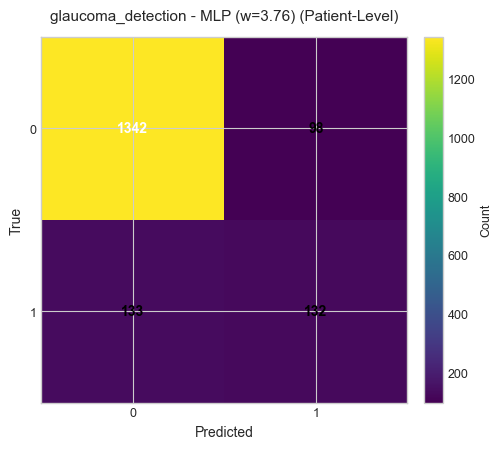

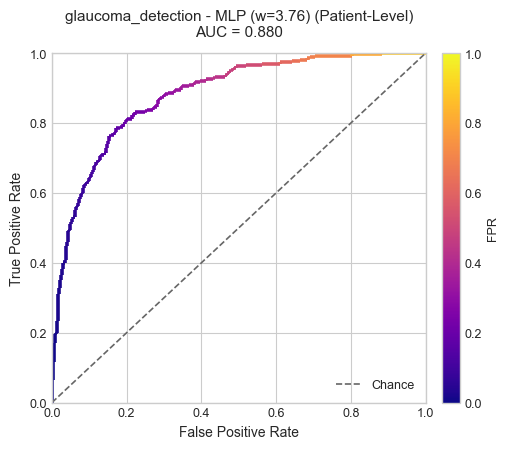


Embedding 2/7: Embeddings_brset_dinov3_convnext_base

--- Task: glaucoma_detection (binary) ---
  Train: 13003 images, 6819 patients
  Test: 3263 images, 1705 patients
  Class distribution (train): {np.int64(0): np.int64(10464), np.int64(1): np.int64(2539)}
  Features: 1024 (raw embeddings, no PCA)

  Training MLP with Bayesian Hyperparameter Search...
  Search space: 12 architectures, pos_class_weight in [1.0, 8.0]
  Bayesian iterations: 25, CV folds: 3, n_jobs: 3
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fit

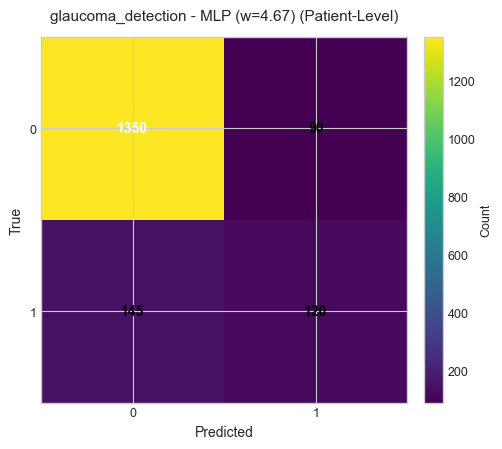

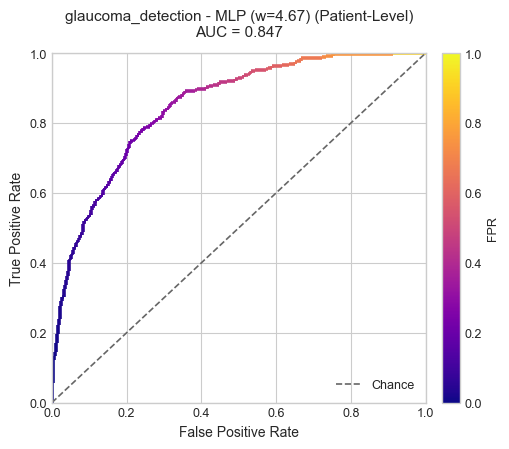


Embedding 3/7: Embeddings_brset_dinov3_vitb16

--- Task: glaucoma_detection (binary) ---
  Train: 13003 images, 6819 patients
  Test: 3263 images, 1705 patients
  Class distribution (train): {np.int64(0): np.int64(10464), np.int64(1): np.int64(2539)}
  Features: 768 (raw embeddings, no PCA)

  Training MLP with Bayesian Hyperparameter Search...
  Search space: 12 architectures, pos_class_weight in [1.0, 8.0]
  Bayesian iterations: 25, CV folds: 3, n_jobs: 3
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fittin

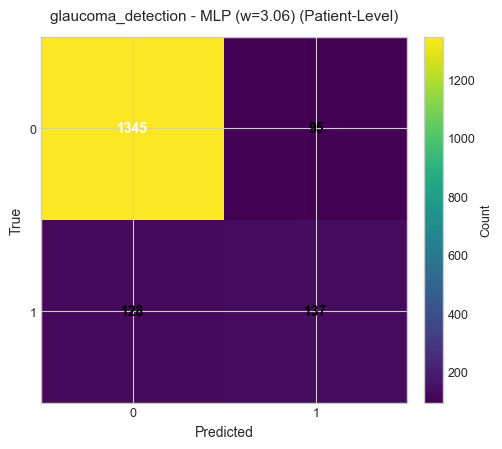

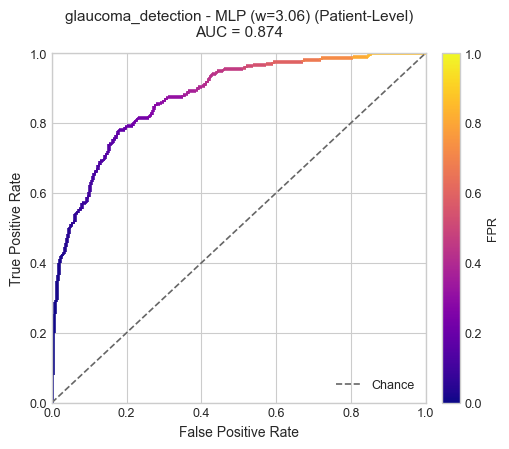


Embedding 4/7: Embeddings_brset_RETFound_dinov2_shanghai

--- Task: glaucoma_detection (binary) ---
  Train: 13003 images, 6819 patients
  Test: 3263 images, 1705 patients
  Class distribution (train): {np.int64(0): np.int64(10464), np.int64(1): np.int64(2539)}
  Features: 1024 (raw embeddings, no PCA)

  Training MLP with Bayesian Hyperparameter Search...
  Search space: 12 architectures, pos_class_weight in [1.0, 8.0]
  Bayesian iterations: 25, CV folds: 3, n_jobs: 3
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3

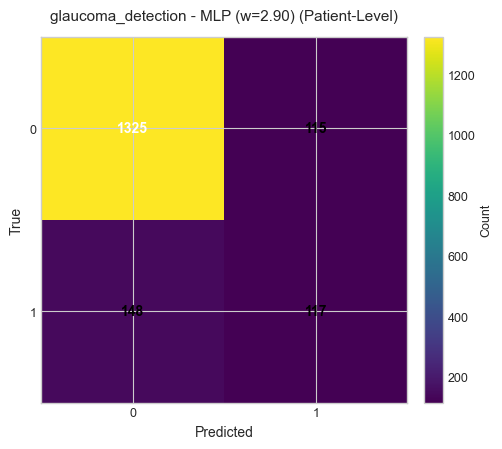

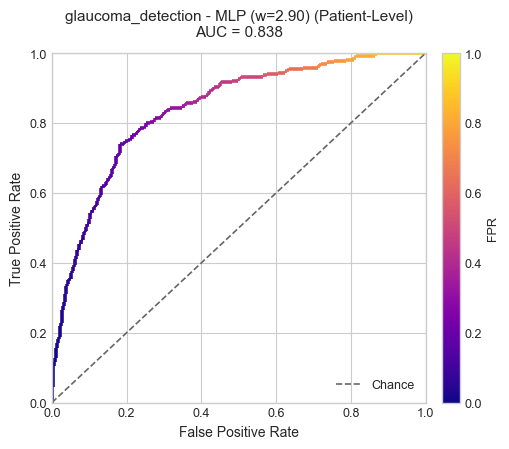


Embedding 5/7: Embeddings_brset_RETFound_mae_natureCFP

--- Task: glaucoma_detection (binary) ---
  Train: 13003 images, 6819 patients
  Test: 3263 images, 1705 patients
  Class distribution (train): {np.int64(0): np.int64(10464), np.int64(1): np.int64(2539)}
  Features: 1024 (raw embeddings, no PCA)

  Training MLP with Bayesian Hyperparameter Search...
  Search space: 12 architectures, pos_class_weight in [1.0, 8.0]
  Bayesian iterations: 25, CV folds: 3, n_jobs: 3
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 f

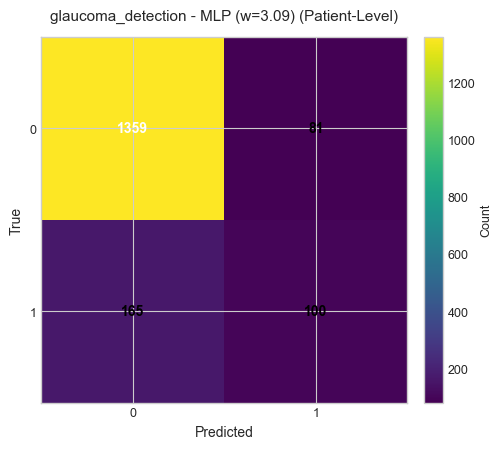

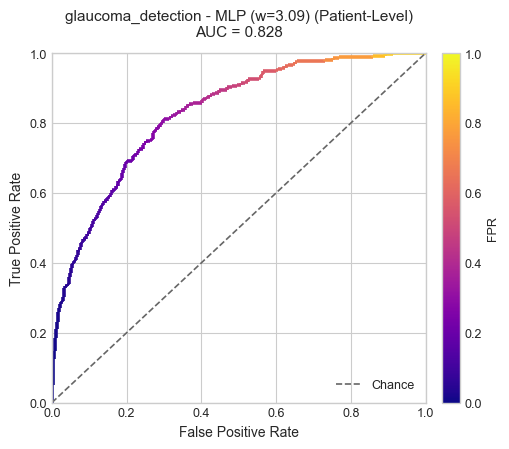


Embedding 6/7: Embeddings_brset_RETFound_mae_shanghai

--- Task: glaucoma_detection (binary) ---
  Train: 13003 images, 6819 patients
  Test: 3263 images, 1705 patients
  Class distribution (train): {np.int64(0): np.int64(10464), np.int64(1): np.int64(2539)}
  Features: 1024 (raw embeddings, no PCA)

  Training MLP with Bayesian Hyperparameter Search...
  Search space: 12 architectures, pos_class_weight in [1.0, 8.0]
  Bayesian iterations: 25, CV folds: 3, n_jobs: 3
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

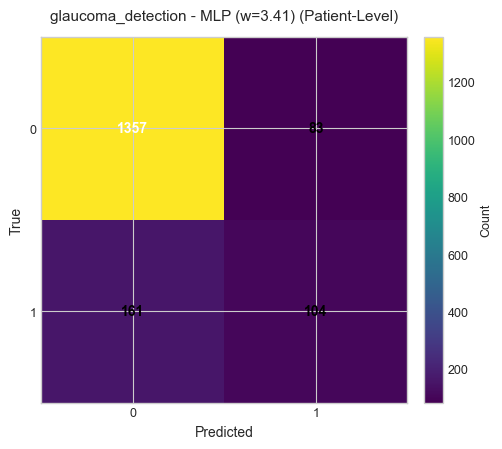

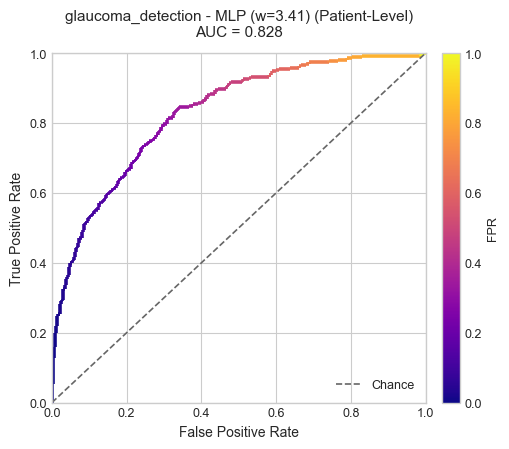


Embedding 7/7: Embeddings_brset_vit_base_

--- Task: glaucoma_detection (binary) ---
  Train: 13003 images, 6819 patients
  Test: 3263 images, 1705 patients
  Class distribution (train): {np.int64(0): np.int64(10464), np.int64(1): np.int64(2539)}
  Features: 768 (raw embeddings, no PCA)

  Training MLP with Bayesian Hyperparameter Search...
  Search space: 12 architectures, pos_class_weight in [1.0, 8.0]
  Bayesian iterations: 25, CV folds: 3, n_jobs: 3
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 

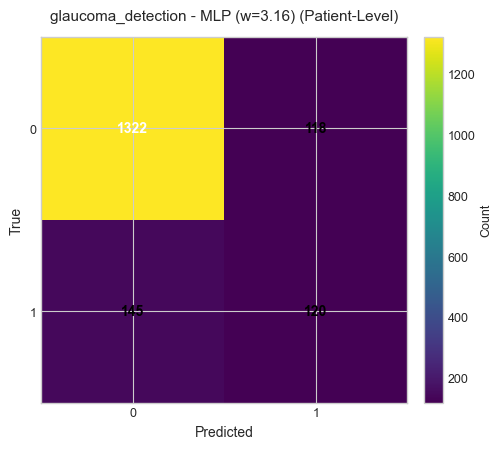

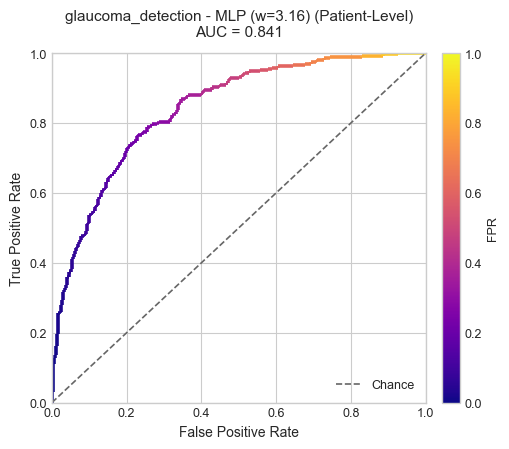


Training and evaluation complete!


In [6]:
# Storage for results
all_results = []

for emb_idx, emb_path in enumerate(embedding_files):
    print(f"\n{'='*80}")
    print(f"Embedding {emb_idx+1}/{len(embedding_files)}: {emb_path.stem}")
    print(f"{'='*80}")
    
    # Load dataset
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME,
        embeddings_csv_path=emb_path,
        labels_csv_path=labels_path,
    )
    
    # Apply split
    train_df, test_df = reval.apply_patient_split(ds.df, split, group_col="patient_id")
    
    # Loop over tasks (single task: increased_cup_disc)
    for task in BINARY_TASKS:
        if task not in ds.df.columns:
            print(f"  WARNING: {task} not found in columns, skipping")
            continue
        
        display_task = BINARY_TASK_MAP.get(task, task)
        
        print(f"\n--- Task: {display_task} (binary) ---")
        
        # Prepare data
        train_work = train_df.dropna(subset=[task]).copy()
        test_work = test_df.dropna(subset=[task]).copy()
        
        if train_work.empty or test_work.empty:
            print(f"  Skipping {task}: insufficient data")
            continue
        
        X_train = train_work.loc[:, ds.feature_cols].to_numpy(dtype=np.float32)
        y_train = train_work[task].astype(int).to_numpy()
        X_test = test_work.loc[:, ds.feature_cols].to_numpy(dtype=np.float32)
        y_test = test_work[task].astype(int).to_numpy()
        
        # Print class distribution
        classes, counts = np.unique(y_train, return_counts=True)
        print(f"  Train: {len(X_train)} images, {train_work['patient_id'].nunique()} patients")
        print(f"  Test: {len(X_test)} images, {test_work['patient_id'].nunique()} patients")
        print(f"  Class distribution (train): {dict(zip(classes.astype(int), counts))}")
        print(f"  Features: {X_train.shape[1]} (raw embeddings, no PCA)")

        # Resolve per-embedding configs
        mlp_cfg, mlp_match = resolve_config(emb_path.stem)
        if mlp_match:
            print(f"  Per-embedding overrides applied (matched: {mlp_match})")

        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Split training data for validation (for threshold optimization)
        from sklearn.model_selection import train_test_split
        X_train_inner, X_val_inner, y_train_inner, y_val_inner = train_test_split(
            X_train_scaled, y_train, test_size=0.15, random_state=RANDOM_SEED, stratify=y_train
        )
        
        print(f"\n  Training MLP with Bayesian Hyperparameter Search...")
        print(f"  Search space: {len(ARCHITECTURE_OPTIONS)} architectures, pos_class_weight in [1.0, 8.0]")
        print(f"  Bayesian iterations: {N_BAYES_ITER}, CV folds: {BAYES_CV_FOLDS}, n_jobs: {BAYES_N_JOBS}")
        
        if USE_BAYESIAN_SEARCH:
            base_mlp = MLPWrapperForBayesSearch(
                max_iter=mlp_cfg["max_epochs"],
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=mlp_cfg["patience"],
                random_state=RANDOM_SEED,
                warm_start=False,
            )
            
            bayes_search = BayesSearchCV(
                estimator=base_mlp,
                search_spaces=SEARCH_SPACE,
                n_iter=N_BAYES_ITER,
                cv=BAYES_CV_FOLDS,
                n_jobs=BAYES_N_JOBS,
                scoring='f1',
                random_state=RANDOM_SEED,
                verbose=1,
            )
            
            bayes_search.fit(X_train_scaled, y_train)
            
            best_model = bayes_search.best_estimator_
            best_params = bayes_search.best_params_
            best_score = bayes_search.best_score_
            
            if 'hidden_layer_sizes' in best_params and isinstance(best_params['hidden_layer_sizes'], int):
                arch_display = ARCHITECTURE_OPTIONS[best_params['hidden_layer_sizes']]
            else:
                arch_display = best_params.get('hidden_layer_sizes', 'unknown')
            
            best_weight = best_params.get('pos_class_weight', 1.0)
            
            print(f"  Best CV F1 Score: {best_score:.4f}")
            print(f"  Best parameters:")
            print(f"    hidden_layer_sizes: {arch_display}")
            print(f"    pos_class_weight: {best_weight:.3f}")
            for key, value in best_params.items():
                if key not in ('hidden_layer_sizes', 'pos_class_weight'):
                    print(f"    {key}: {value}")
        
        else:
            print(f"  Training with default config (no Bayesian search)")
            best_model = MLPClassifier(
                hidden_layer_sizes=mlp_cfg["hidden_layer_sizes"],
                alpha=mlp_cfg["alpha"],
                learning_rate_init=mlp_cfg["learning_rate_init"],
                batch_size=mlp_cfg["batch_size"],
                max_iter=mlp_cfg["max_epochs"],
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=mlp_cfg["patience"],
                random_state=RANDOM_SEED,
            )
            best_model.fit(X_train_scaled, y_train)
            best_weight = 1.0
        
        # Find optimal threshold on validation set
        val_proba = best_model.predict_proba(X_val_inner)[:, 1]
        opt_thresh = find_optimal_threshold(y_val_inner, val_proba, method=THRESHOLD_METHOD)
        print(f"  Optimal threshold ({THRESHOLD_METHOD}): {opt_thresh:.3f}")
        
        # Get predictions on test set
        y_proba_test = best_model.predict_proba(X_test_scaled)[:, 1]
        y_pred_test = (y_proba_test >= opt_thresh).astype(int)
        
        # Create image-level results DataFrame
        test_results = test_work[["patient_id"]].copy()
        test_results["y_true"] = y_test
        test_results["y_pred"] = y_pred_test
        test_results["y_proba"] = y_proba_test
        
        # Aggregate to patient level
        patient_results = aggregate_patient_predictions(test_results, group_col="patient_id")
        
        y_true_patient = patient_results["y_true"].to_numpy()
        y_pred_patient = patient_results["y_pred"].to_numpy()
        y_proba_patient = patient_results["y_proba"].to_numpy()
        
        # Calculate comprehensive metrics
        from sklearn.metrics import f1_score, precision_score, recall_score, balanced_accuracy_score
        
        accuracy = (y_true_patient == y_pred_patient).mean()
        f1 = f1_score(y_true_patient, y_pred_patient, zero_division=0)
        precision = precision_score(y_true_patient, y_pred_patient, zero_division=0)
        recall = recall_score(y_true_patient, y_pred_patient, zero_division=0)
        balanced_acc = balanced_accuracy_score(y_true_patient, y_pred_patient)
        fpr, tpr, _ = roc_curve(y_true_patient, y_proba_patient)
        auc = roc_auc_score(y_true_patient, y_proba_patient)
        
        weight_label = f"w={best_weight:.2f}" if USE_BAYESIAN_SEARCH else "unweighted"
        
        print(f"\n  Patient-Level Metrics:")
        print(f"  Accuracy: {accuracy:.3f}")
        print(f"  Balanced Accuracy: {balanced_acc:.3f}")
        print(f"  F1 Score: {f1:.3f}")
        print(f"  Precision: {precision:.3f}")
        print(f"  Recall (Sensitivity): {recall:.3f}")
        print(f"  ROC AUC: {auc:.3f}")
        print(f"  Best pos_class_weight: {best_weight:.3f}")
        
        report_text = classification_report(y_true_patient, y_pred_patient, digits=3)
        print(f"\n  Classification Report (Patient-Level):")
        print(report_text)
        
        cm = confusion_matrix(y_true_patient, y_pred_patient)
        
        # Save outputs
        out_dir = RESULTS_DIR / f"{emb_idx:02d}_{emb_path.stem}" / display_task / "mlp"
        out_dir.mkdir(parents=True, exist_ok=True)
        
        (out_dir / "classification_report.txt").write_text(report_text, encoding="utf-8")
        
        if USE_BAYESIAN_SEARCH:
            import json
            save_params = {k: str(v) for k, v in best_params.items()}
            if 'hidden_layer_sizes' in best_params and isinstance(best_params['hidden_layer_sizes'], int):
                save_params['hidden_layer_sizes_resolved'] = str(arch_display)
            with open(out_dir / "best_hyperparameters.json", "w") as f:
                json.dump(save_params, f, indent=2)
        
        pd.DataFrame(cm).to_csv(out_dir / "confusion_matrix.csv", index=False)
        plot_confusion_matrix(
            cm,
            title=f"{display_task} - MLP ({weight_label}) (Patient-Level)",
            save_path=out_dir / "confusion_matrix.png" if SAVE_PLOTS else None,
            show=SHOW_PLOTS,
        )
        
        pd.DataFrame({"fpr": fpr, "tpr": tpr}).to_csv(out_dir / "roc_curve.csv", index=False)
        plot_roc_curve(
            fpr, tpr, auc,
            title=f"{display_task} - MLP ({weight_label}) (Patient-Level)",
            save_path=out_dir / "roc_curve.png" if SAVE_PLOTS else None,
            show=SHOW_PLOTS,
        )
        
        patient_results.to_csv(out_dir / "patient_predictions.csv", index=False)
        
        all_results.append({
            "embedding_idx": emb_idx,
            "embedding": emb_path.stem,
            "task": display_task,
            "model": "mlp",
            "pos_class_weight": float(best_weight),
            "n_patients": len(patient_results),
            "accuracy": float(accuracy),
            "balanced_accuracy": float(balanced_acc),
            "f1_score": float(f1),
            "precision": float(precision),
            "recall": float(recall),
            "auc": float(auc),
            "best_cv_score": float(best_score) if USE_BAYESIAN_SEARCH else None,
            "output_dir": str(out_dir),
        })

print(f"\n{'='*80}")
print("Training and evaluation complete!")
print(f"{'='*80}")

## 6. Summary Table

In [7]:
# Create summary DataFrame
summary_df = pd.DataFrame(all_results)

# Save summary
summary_df.to_csv(RESULTS_DIR / "summary.csv", index=False)
print(f"Saved summary to: {RESULTS_DIR / 'summary.csv'}")

# Display summary
print("\nSummary of Results (Patient-Level) — Glaucoma Detection:")
display_cols = ["embedding", "task", "model", "pos_class_weight", "n_patients",
                "accuracy", "balanced_accuracy", "f1_score", "recall", "auc"]
if USE_BAYESIAN_SEARCH and "best_cv_score" in summary_df.columns:
    display_cols.insert(5, "best_cv_score")
print(summary_df[display_cols].to_string(index=False))

summary_df

Saved summary to: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_patient_eval_glaucoma\summary.csv

Summary of Results (Patient-Level) — Glaucoma Detection:
                                embedding               task model  pos_class_weight  n_patients  best_cv_score  accuracy  balanced_accuracy  f1_score   recall      auc
        Embeddings_brset_convnextv2_base_ glaucoma_detection   mlp          3.759697        1705       0.566951  0.864516           0.715029  0.533333 0.498113 0.879625
    Embeddings_brset_dinov3_convnext_base glaucoma_detection   mlp          4.668169        1705       0.521195  0.862170           0.695165  0.505263 0.452830 0.847356
           Embeddings_brset_dinov3_vitb16 glaucoma_detection   mlp          3.055947        1705       0.577352  0.869208           0.725504  0.551308 0.516981 0.874494
Embeddings_brset_RETFound_dinov2_shanghai glaucoma_detection   mlp          2.904592        1705       0.

,embedding_idx,embedding,task,model,pos_class_weight,n_patients,accuracy,balanced_accuracy,f1_score,precision,recall,auc,best_cv_score,output_dir
0,0,Embeddings_brset_convnextv2_base_,glaucoma_detection,mlp,3.759697,1705,0.864516,0.715029,0.533333,0.573913,0.498113,0.879625,0.566951,c:\Users\Julian\OneDrive\Desktop\testing-retin...
1,1,Embeddings_brset_dinov3_convnext_base,glaucoma_detection,mlp,4.668169,1705,0.862170,0.695165,0.505263,0.571429,0.452830,0.847356,0.521195,c:\Users\Julian\OneDrive\Desktop\testing-retin...
2,2,Embeddings_brset_dinov3_vitb16,glaucoma_detection,mlp,3.055947,1705,0.869208,0.725504,0.551308,0.590517,0.516981,0.874494,0.577352,c:\Users\Julian\OneDrive\Desktop\testing-retin...
3,3,Embeddings_brset_RETFound_dinov2_shanghai,glaucoma_detection,mlp,2.904592,1705,0.845748,0.680824,0.470825,0.504310,0.441509,0.837529,0.533395,c:\Users\Julian\OneDrive\Desktop\testing-retin...
4,4,Embeddings_brset_RETFound_mae_natureCFP,glaucoma_detection,mlp,3.088753,1705,0.855718,0.660554,0.448430,0.552486,0.377358,0.827534,0.513039,c:\Users\Julian\OneDrive\Desktop\testing-retin...
5,5,Embeddings_brset_RETFound_mae_shanghai,glaucoma_detection,mlp,3.408825,1705,0.856891,0.667407,0.460177,0.556150,0.392453,0.827757,0.537043,c:\Users\Julian\OneDrive\Desktop\testing-retin...
6,6,Embeddings_brset_vit_base_,glaucoma_detection,mlp,3.155152,1705,0.845748,0.685443,0.477137,0.504202,0.452830,0.840501,0.531156,c:\Users\Julian\OneDrive\Desktop\testing-retin...


## 7. Training Dynamics Analysis

Generate training curves showing train vs validation loss to detect overfitting/underfitting.
Uses an **internal validation split** from the training set (not the test set).

In [ ]:
# Training dynamics: track train vs validation loss
# Uses the best pos_class_weight found during Bayesian search (from all_results)
MAX_EMBEDDINGS_FOR_DYNAMICS = 7
DYNAMICS_DIR = RESULTS_DIR / "training_dynamics"
DYNAMICS_DIR.mkdir(parents=True, exist_ok=True)

# Build a lookup for best weight per embedding from the main evaluation
best_weight_lookup = {}
for r in all_results:
    best_weight_lookup[r["embedding"]] = r.get("pos_class_weight", 1.0)

print(f"Running training dynamics analysis...")
print(f"Max embeddings: {MAX_EMBEDDINGS_FOR_DYNAMICS if MAX_EMBEDDINGS_FOR_DYNAMICS else 'all'}")

dynamics_embeddings = embedding_files[:MAX_EMBEDDINGS_FOR_DYNAMICS] if MAX_EMBEDDINGS_FOR_DYNAMICS else embedding_files

for emb_idx, emb_path in enumerate(dynamics_embeddings):
    print(f"\n{'='*70}")
    print(f"Embedding {emb_idx+1}/{len(dynamics_embeddings)}: {emb_path.stem}")
    print(f"{'='*70}")
    
    # Load dataset
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME,
        embeddings_csv_path=emb_path,
        labels_csv_path=labels_path,
    )
    
    # Apply split
    train_df, test_df = reval.apply_patient_split(ds.df, split, group_col="patient_id")
    
    # Loop over tasks (single task: increased_cup_disc)
    for task in BINARY_TASKS:
        if task not in ds.df.columns:
            continue
        
        display_task = BINARY_TASK_MAP.get(task, task)
        
        print(f"\n--- Task: {display_task} (binary) ---")
        
        train_work = train_df.dropna(subset=[task]).copy()
        
        if train_work.empty:
            print(f"  Skipping {task}: insufficient data")
            continue
        
        X_train_full = train_work.loc[:, ds.feature_cols].to_numpy(dtype=np.float32)
        y_train_full = train_work[task].astype(int).to_numpy()
        
        # Create internal validation split
        from sklearn.model_selection import train_test_split
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_full, y_train_full, test_size=0.15, random_state=RANDOM_SEED, stratify=y_train_full
        )
        
        print(f"  Train: {len(X_train)} images")
        print(f"  Internal Val: {len(X_val)} images")
        print(f"  Features: {X_train.shape[1]} (raw embeddings, no PCA)")
        
        mlp_cfg, mlp_match = resolve_config(emb_path.stem)
        if mlp_match:
            print(f"  Per-embedding overrides applied (matched: {mlp_match})")
        
        # Use best weight from Bayesian search
        dyn_weight = best_weight_lookup.get(emb_path.stem, 1.0)
        print(f"  Using pos_class_weight={dyn_weight:.3f} (from Bayesian search)")
        
        print(f"\n  Training MLP with dynamics tracking...")
        warmup = mlp_cfg.get("warmup_epochs", 0)
        print(f"  Config: hidden={mlp_cfg['hidden_layer_sizes']}, alpha={mlp_cfg['alpha']}, lr={mlp_cfg['learning_rate_init']}, warmup={warmup}")
        print(f"  Batch size: {mlp_cfg['batch_size']}, Patience: {mlp_cfg['patience']}")
        
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_val_s = scaler.transform(X_val)
        
        # Build sample weights
        train_weights = make_sample_weights(y_train, pos_class_weight=dyn_weight)
        val_weights = make_sample_weights(y_val, pos_class_weight=dyn_weight)
        
        mlp = MLPClassifier(
            hidden_layer_sizes=mlp_cfg["hidden_layer_sizes"],
            alpha=mlp_cfg["alpha"],
            learning_rate_init=mlp_cfg["learning_rate_init"],
            batch_size=mlp_cfg["batch_size"],
            max_iter=1,
            warm_start=True,
            early_stopping=False,
            random_state=RANDOM_SEED,
        )
        
        mlp_train_loss = []
        mlp_val_loss = []
        best_val_loss = float("inf")
        best_epoch = 0
        best_model_dyn = None
        patience_counter = 0
        
        labels = np.unique(np.concatenate([y_train, y_val]))
        
        for epoch in range(1, mlp_cfg["max_epochs"] + 1):
            mlp.fit(X_train_s, y_train, sample_weight=train_weights)
            
            train_proba = mlp.predict_proba(X_train_s)
            val_proba = mlp.predict_proba(X_val_s)
            
            tr_loss = float(weighted_log_loss(y_train, train_proba, labels=labels, sample_weight=train_weights))
            va_loss = float(weighted_log_loss(y_val, val_proba, labels=labels, sample_weight=val_weights))
            
            mlp_train_loss.append(tr_loss)
            mlp_val_loss.append(va_loss)
            
            if va_loss < best_val_loss - mlp_cfg["min_delta"]:
                best_val_loss = va_loss
                best_epoch = epoch
                best_model_dyn = copy.deepcopy(mlp)
                patience_counter = 0
            elif epoch > warmup:
                patience_counter += 1
                if patience_counter >= mlp_cfg["patience"]:
                    break
        
        mlp_stop_epoch = len(mlp_val_loss)
        
        print(f"  Best epoch: {best_epoch}, Stopped at: {mlp_stop_epoch}")
        print(f"  Final train loss: {mlp_train_loss[-1]:.4f}, val loss: {mlp_val_loss[best_epoch-1]:.4f}")
        
        # --- Plot Training Dynamics ---
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
        epochs = np.arange(1, len(mlp_train_loss) + 1)
        ax.plot(epochs, mlp_train_loss, label="Train loss", linewidth=2.4, color="#2E86AB")
        ax.plot(epochs, mlp_val_loss, label="Validation loss", linewidth=2.4, color="#A23B72")
        ax.axvline(best_epoch, linestyle="--", linewidth=1.5, color="#F18F01",
                   label=f"Best epoch={best_epoch}")
        ax.set_xlabel("Epochs", fontsize=11)
        ax.set_ylabel("Log Loss", fontsize=11)
        ax.set_title(f"MLP Training Dynamics - {display_task} (w={dyn_weight:.2f})\n{emb_path.stem}", fontsize=12, pad=10)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        
        final_gap_mlp = mlp_train_loss[-1] - mlp_val_loss[best_epoch-1]
        ax.text(0.98, 0.02, f"Train-Val Gap: {final_gap_mlp:.4f}", 
                transform=ax.transAxes, fontsize=10, verticalalignment='bottom',
                horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        
        out_name = f"dynamics_{emb_idx:02d}_{emb_path.stem}_{display_task}.png"
        fig.savefig(DYNAMICS_DIR / out_name, dpi=160, bbox_inches="tight")
        
        if SHOW_PLOTS:
            plt.show()
        else:
            plt.close(fig)
        
        mlp_df = pd.DataFrame({
            "epoch": epochs,
            "train_loss": mlp_train_loss,
            "val_loss": mlp_val_loss,
        })
        mlp_df.to_csv(DYNAMICS_DIR / f"mlp_{emb_idx:02d}_{emb_path.stem}_{display_task}.csv", index=False)


print(f"\n{'='*70}")
print(f"Training dynamics complete!")

## Summary

This notebook performed patient-level glaucoma detection evaluation on **BRSET** using:
- **Target**: `increased_cup_disc` (increased cup-to-disc ratio — glaucoma surrogate)
- **Single 80/20 patient split** (reused for all embeddings)
- **MLP with Bayesian hyperparameter search** (BayesSearchCV, 25 iterations, parallel CV)
- **No PCA** — raw embedding features used directly (768 or 1024 dims)
- **Class weight search** — `pos_class_weight` (1.0–8.0) searched per embedding
- **Architecture**: 12 options searched (128 to 1024 neurons, 1-3 layers)
- **Batch sizes**: [64, 128, 256]
- **Alpha regularization**: Searched 1e-5 to 1e-1 (log-uniform)
- **Learning rate**: Searched 1e-4 to 1e-3 (log-uniform)
- **Patient-level aggregation** (majority vote + averaged probabilities)

**mBRSET note**: Glaucoma evaluation is **not possible** on mBRSET — no `increased_cup_disc` column exists in the mBRSET labels dataset.

All results are saved in `results/brset_patient_eval_glaucoma/`.

## Phase 2 — Aggressive Refinement (pushing toward clinical-grade F1)

Phase 1 discovered optimal weights per embedding (range 2.9-4.7). F1 scores are 0.45-0.55, not yet clinical-grade.

**Phase 2 strategy:**
1. Lock in best architecture/alpha/lr from Phase 1 per embedding
2. Aggressive weight sweep: fine-grained search around Phase 1 weight, expanded range up to 15
3. Youden threshold: maximizes sensitivity + specificity jointly (better for clinical screening)
4. Multi-threshold reporting: metrics at Youden, F1-optimal, and high-sensitivity (recall >= 0.85) thresholds
5. Deeper architectures explored around the best ones found
6. Score on `balanced_accuracy` to force minority class improvement

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# PHASE 2 — Aggressive Refinement with locked-in best hyperparameters
# ═══════════════════════════════════════════════════════════════════════════════

import json

# Build per-embedding configs from Phase 1 results
PHASE1_CONFIGS = {}
for r in all_results:
    emb_name = r["embedding"]
    # Read the best hyperparameters JSON
    hp_path = Path(r["output_dir"]) / "best_hyperparameters.json"
    with open(hp_path) as f:
        hp = json.load(f)
    
    arch_idx = int(hp["hidden_layer_sizes"])
    PHASE1_CONFIGS[emb_name] = {
        "arch_idx": arch_idx,
        "arch": ARCHITECTURE_OPTIONS[arch_idx],
        "alpha": float(hp["alpha"]),
        "lr": float(hp["learning_rate_init"]),
        "batch_size": int(hp["batch_size"]),
        "phase1_weight": float(hp["pos_class_weight"]),
        "phase1_f1": r["f1_score"],
        "phase1_auc": r["auc"],
    }

print("Phase 1 best configs loaded:")
for name, cfg in PHASE1_CONFIGS.items():
    short = name.replace("Embeddings_brset_", "")
    print(f"  {short}: arch={cfg['arch']}, w={cfg['phase1_weight']:.2f}, "
          f"F1={cfg['phase1_f1']:.3f}, AUC={cfg['phase1_auc']:.3f}")

# Phase 2 search: aggressive weight range + nearby architectures + balanced_accuracy scoring
PHASE2_N_ITER = 30
PHASE2_MAX_EPOCHS = 300
PHASE2_PATIENCE = 25

# For each embedding, build architecture candidates: base arch + deeper/wider variants
def get_phase2_architectures(base_arch):
    """Generate architecture candidates around the Phase 1 best."""
    candidates = [base_arch]  # always include the winner
    n_layers = len(base_arch)
    max_width = max(base_arch)
    
    # Wider variant
    wider = tuple(min(w * 2, 1024) for w in base_arch)
    if wider != base_arch:
        candidates.append(wider)
    
    # Deeper variant (+1 layer)
    if n_layers == 1:
        candidates.append((max_width, max_width))
        candidates.append((max_width, max_width // 2))
    elif n_layers == 2:
        candidates.append(base_arch + (base_arch[-1] // 2,))
        candidates.append(base_arch + (base_arch[-1],))
    elif n_layers == 3:
        candidates.append((max_width,) + base_arch)
    
    # Add some strong general architectures
    for extra in [(512, 256, 128), (1024, 512, 256), (512, 512), (256, 256, 256)]:
        if extra not in candidates:
            candidates.append(extra)
    
    # Deduplicate
    seen = set()
    unique = []
    for c in candidates:
        if c not in seen:
            seen.add(c)
            unique.append(c)
    
    return unique

print(f"\nPhase 2 config: {PHASE2_N_ITER} Bayesian iters, {PHASE2_MAX_EPOCHS} max epochs, "
      f"patience={PHASE2_PATIENCE}, scoring=balanced_accuracy")

Phase 1 best configs loaded:
  convnextv2_base_: arch=(256,), w=3.76, F1=0.533, AUC=0.880
  dinov3_convnext_base: arch=(512,), w=4.67, F1=0.505, AUC=0.847
  dinov3_vitb16: arch=(128,), w=3.06, F1=0.551, AUC=0.874
  RETFound_dinov2_shanghai: arch=(128,), w=2.90, F1=0.471, AUC=0.838
  RETFound_mae_natureCFP: arch=(128,), w=3.09, F1=0.448, AUC=0.828
  RETFound_mae_shanghai: arch=(512,), w=3.41, F1=0.460, AUC=0.828
  vit_base_: arch=(512,), w=3.16, F1=0.477, AUC=0.841

Phase 2 config: 30 Bayesian iters, 300 max epochs, patience=25, scoring=balanced_accuracy



PHASE 2 — Embedding 1/7: convnextv2_base_
Phase 1 baseline: F1=0.533, AUC=0.880, w=3.76
  Architecture candidates (8): [(256,), (512,), (256, 256), (256, 128), (512, 256, 128), (1024, 512, 256), (512, 512), (256, 256, 256)]
  Weight search range: [1.8, 11.8] (Phase 1 best: 3.76)

  Running Phase 2 Bayesian search (30 iters, scoring=balanced_accuracy)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3

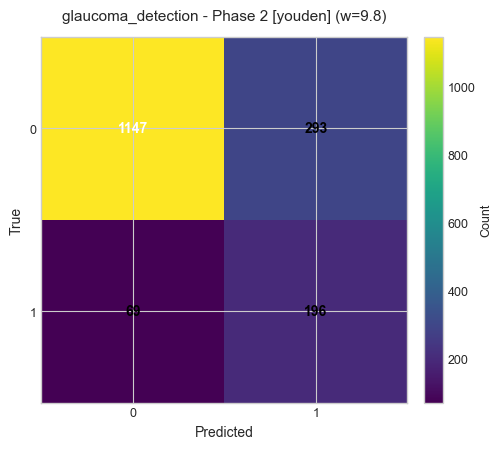

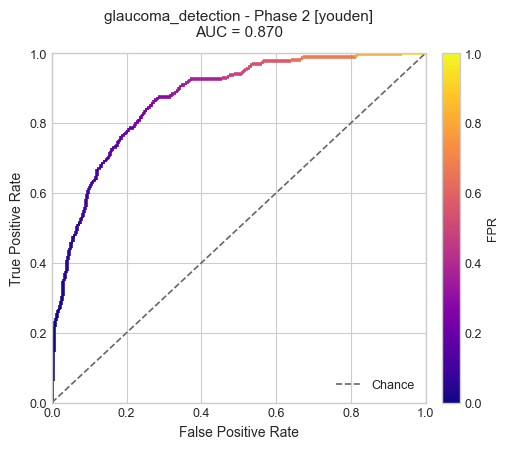


  [f1_optimal] threshold=0.814
    Accuracy=0.869, Bal.Acc=0.693, F1=0.510, Prec=0.611, Recall=0.438, AUC=0.870


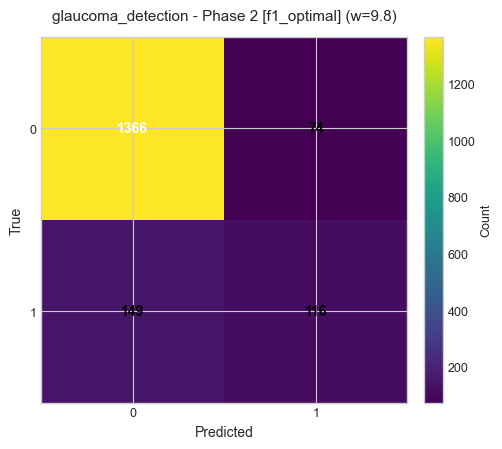

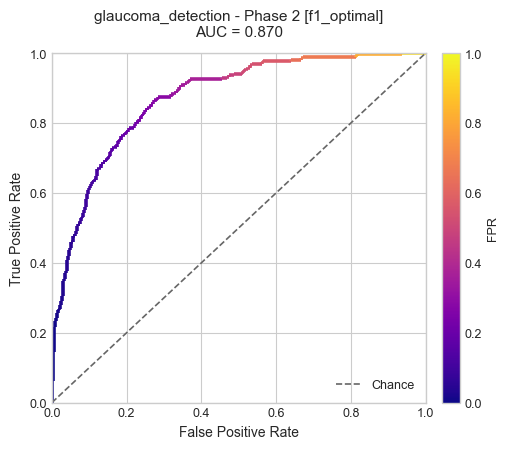


  [high_sensitivity] threshold=0.647
    Accuracy=0.813, Bal.Acc=0.760, F1=0.532, Prec=0.435, Recall=0.683, AUC=0.870


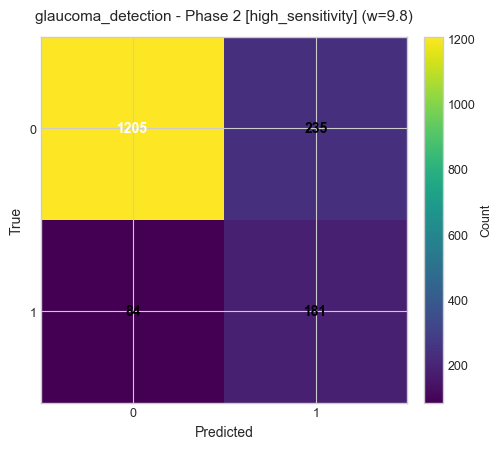

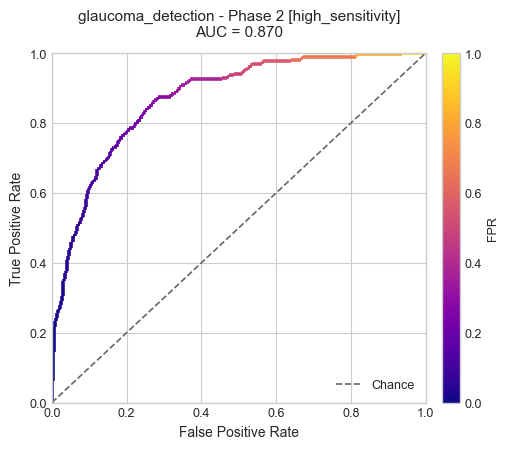


  >>> Best threshold for convnextv2_base_: high_sensitivity (F1=0.532)

PHASE 2 — Embedding 2/7: dinov3_convnext_base
Phase 1 baseline: F1=0.505, AUC=0.847, w=4.67
  Architecture candidates (7): [(512,), (1024,), (512, 512), (512, 256), (512, 256, 128), (1024, 512, 256), (256, 256, 256)]
  Weight search range: [2.7, 12.7] (Phase 1 best: 4.67)

  Running Phase 2 Bayesian search (30 iters, scoring=balanced_accuracy)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, total

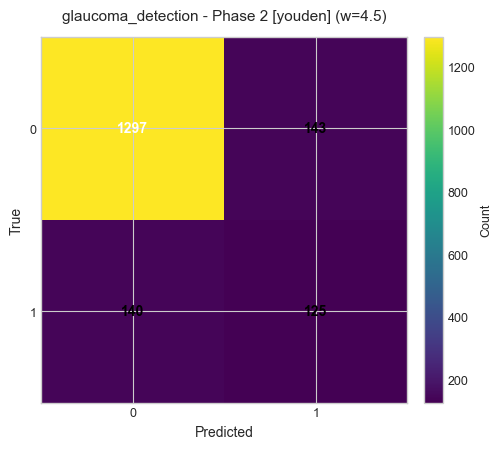

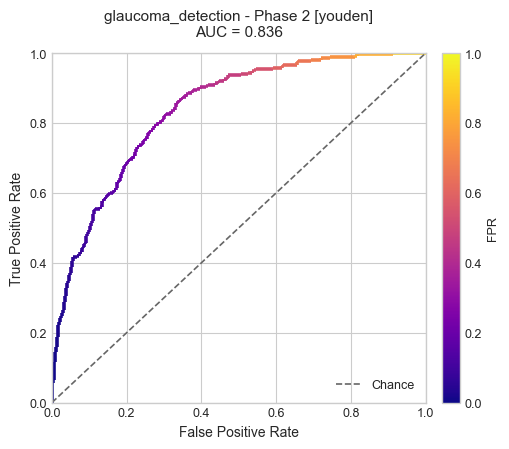


  [f1_optimal] threshold=0.676
    Accuracy=0.852, Bal.Acc=0.638, F1=0.407, Prec=0.537, Recall=0.328, AUC=0.836


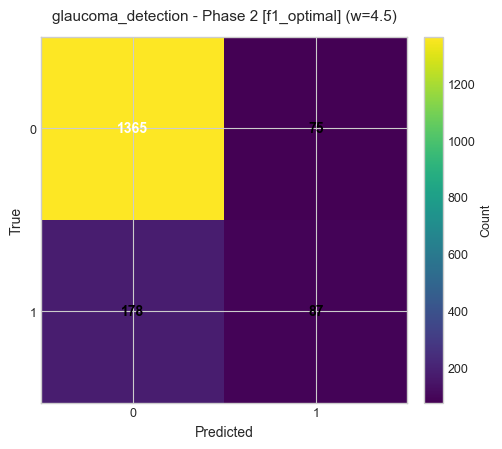

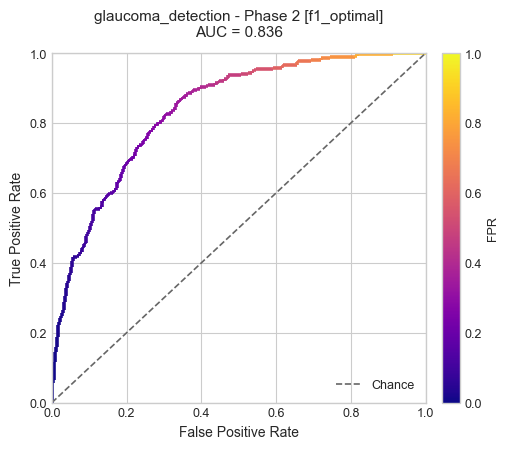


  [high_sensitivity] threshold=0.510
    Accuracy=0.821, Bal.Acc=0.700, F1=0.477, Prec=0.437, Recall=0.525, AUC=0.836


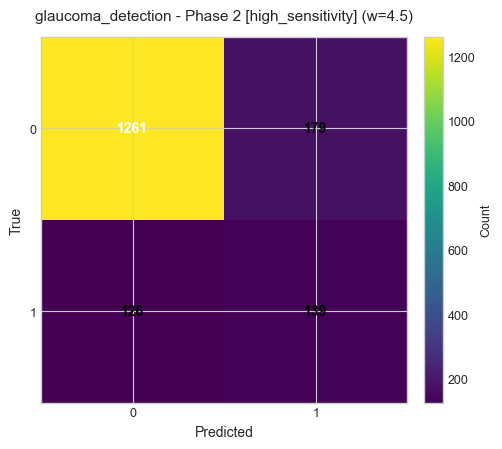

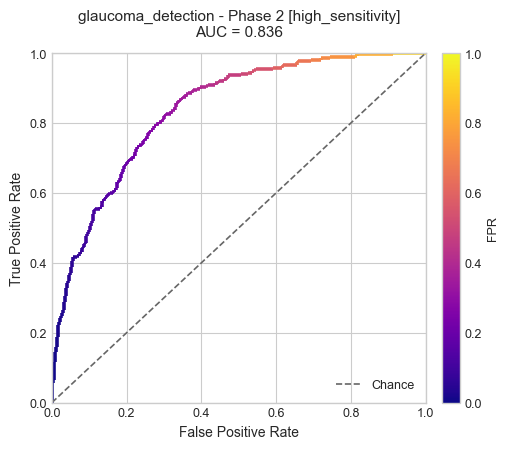


  >>> Best threshold for dinov3_convnext_base: high_sensitivity (F1=0.477)

PHASE 2 — Embedding 3/7: dinov3_vitb16
Phase 1 baseline: F1=0.551, AUC=0.874, w=3.06
  Architecture candidates (8): [(128,), (256,), (128, 128), (128, 64), (512, 256, 128), (1024, 512, 256), (512, 512), (256, 256, 256)]
  Weight search range: [1.1, 11.1] (Phase 1 best: 3.06)

  Running Phase 2 Bayesian search (30 iters, scoring=balanced_accuracy)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates

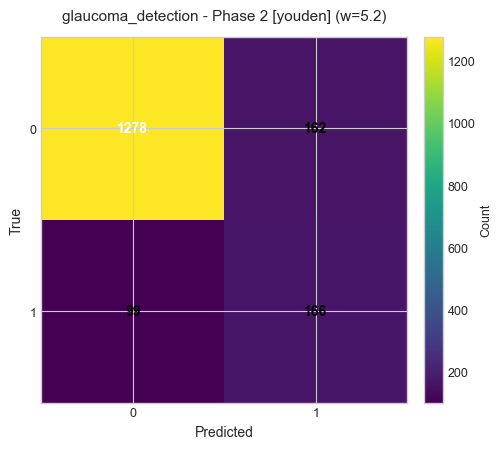

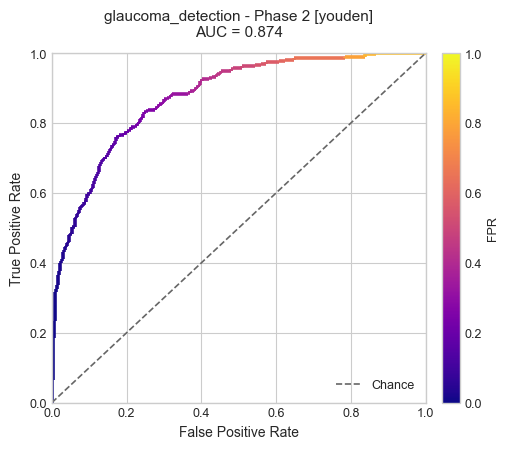


  [f1_optimal] threshold=0.662
    Accuracy=0.866, Bal.Acc=0.724, F1=0.546, Prec=0.578, Recall=0.517, AUC=0.874


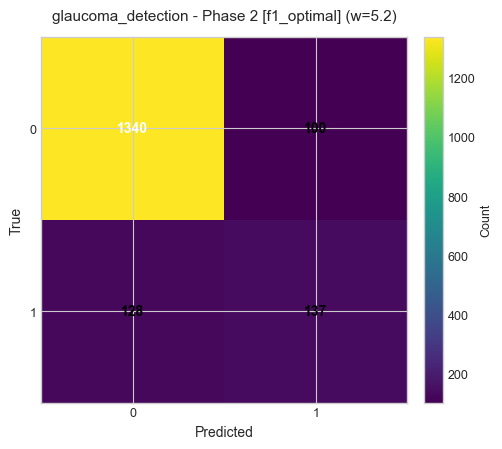

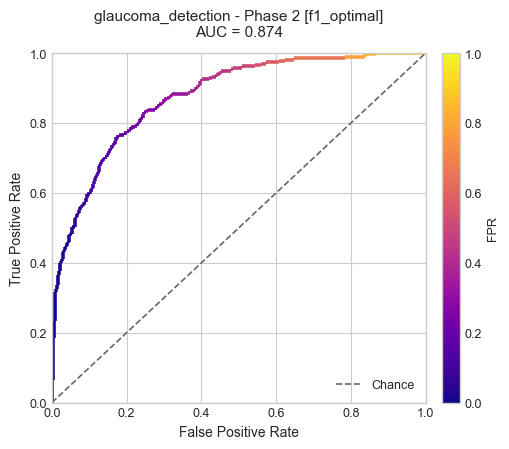


  [high_sensitivity] threshold=0.574
    Accuracy=0.850, Bal.Acc=0.747, F1=0.553, Prec=0.516, Recall=0.596, AUC=0.874


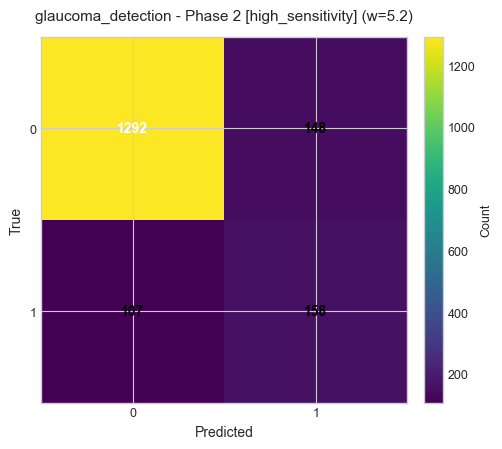

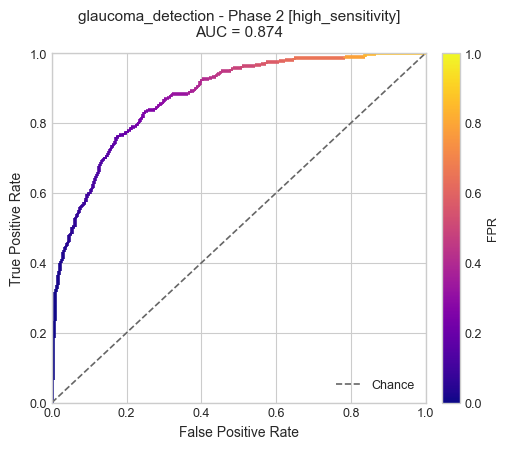


  >>> Best threshold for dinov3_vitb16: youden (F1=0.560)

PHASE 2 — Embedding 4/7: RETFound_dinov2_shanghai
Phase 1 baseline: F1=0.471, AUC=0.838, w=2.90
  Architecture candidates (8): [(128,), (256,), (128, 128), (128, 64), (512, 256, 128), (1024, 512, 256), (512, 512), (256, 256, 256)]
  Weight search range: [1.0, 10.9] (Phase 1 best: 2.90)

  Running Phase 2 Bayesian search (30 iters, scoring=balanced_accuracy)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, tota

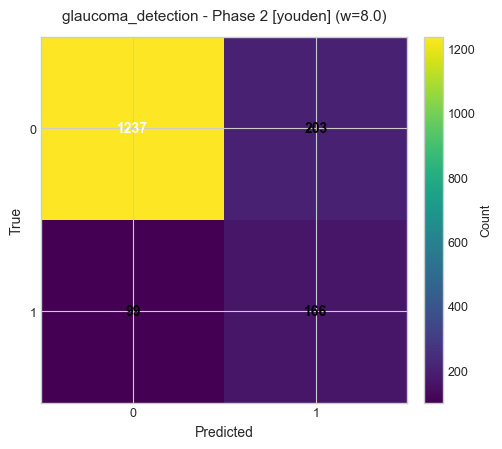

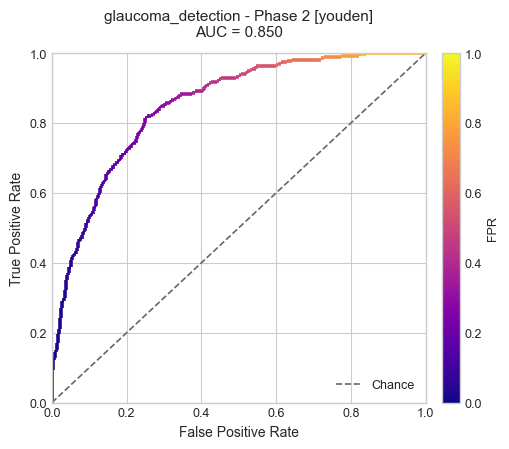


  [f1_optimal] threshold=0.740
    Accuracy=0.855, Bal.Acc=0.686, F1=0.485, Prec=0.539, Recall=0.442, AUC=0.850


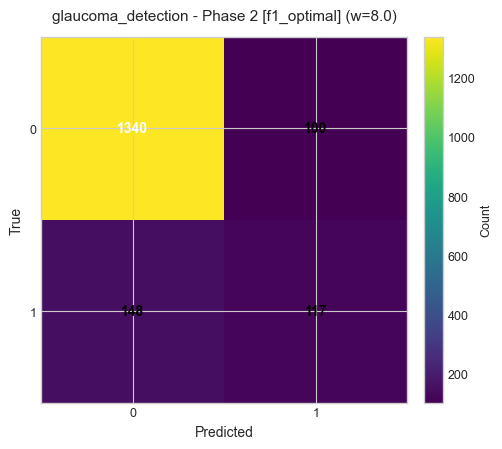

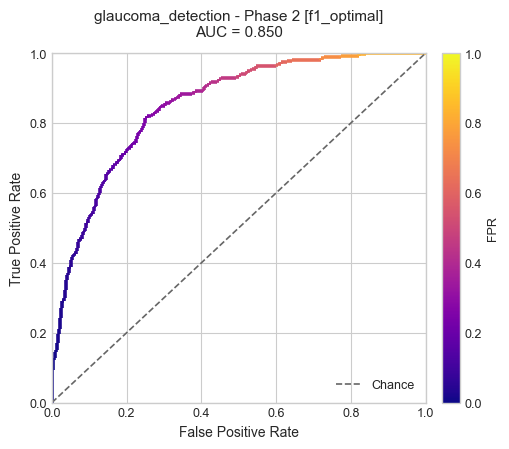


  [high_sensitivity] threshold=0.681
    Accuracy=0.842, Bal.Acc=0.702, F1=0.495, Prec=0.493, Recall=0.498, AUC=0.850


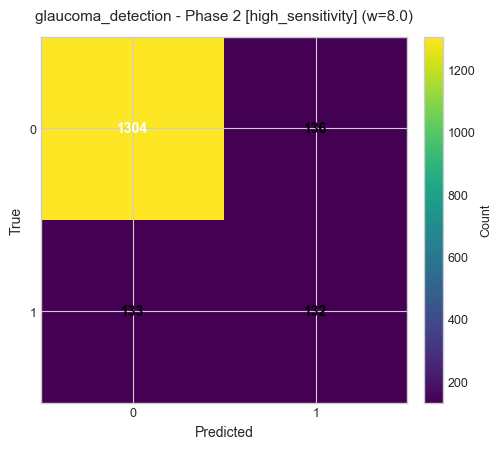

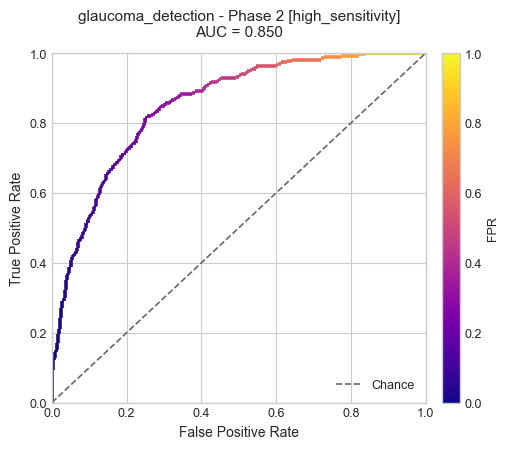


  >>> Best threshold for RETFound_dinov2_shanghai: youden (F1=0.524)

PHASE 2 — Embedding 5/7: RETFound_mae_natureCFP
Phase 1 baseline: F1=0.448, AUC=0.828, w=3.09
  Architecture candidates (8): [(128,), (256,), (128, 128), (128, 64), (512, 256, 128), (1024, 512, 256), (512, 512), (256, 256, 256)]
  Weight search range: [1.1, 11.1] (Phase 1 best: 3.09)

  Running Phase 2 Bayesian search (30 iters, scoring=balanced_accuracy)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candida

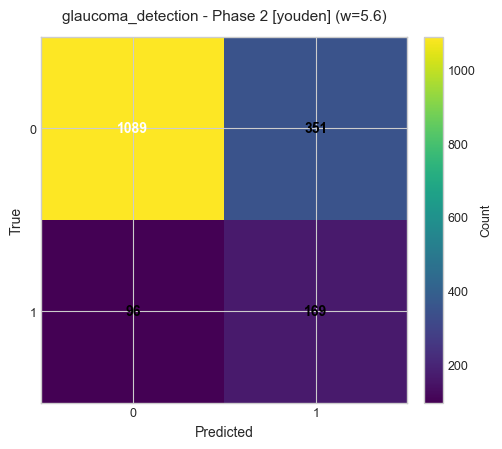

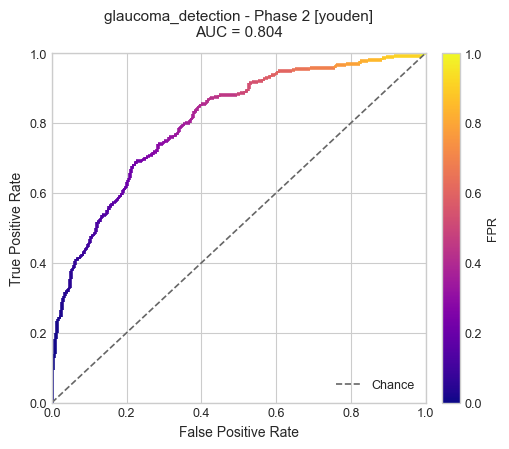


  [f1_optimal] threshold=0.667
    Accuracy=0.836, Bal.Acc=0.683, F1=0.467, Prec=0.473, Recall=0.460, AUC=0.804


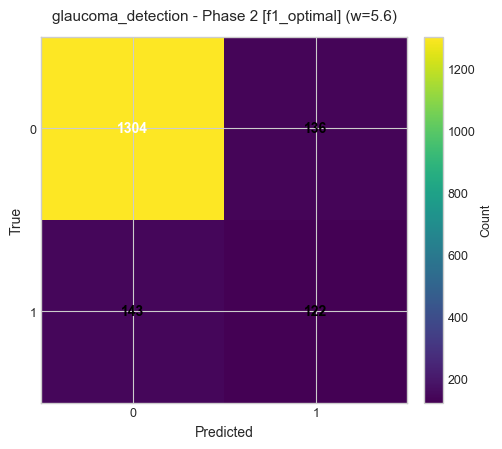

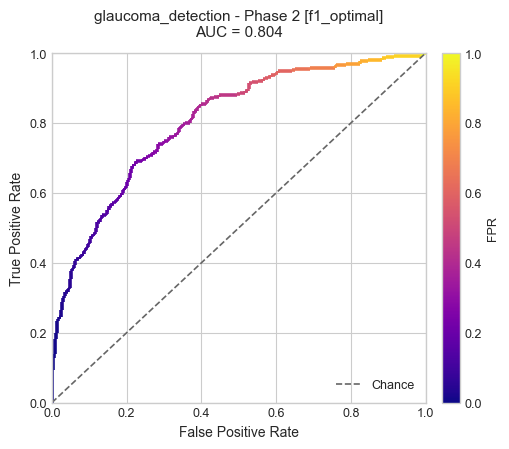


  [high_sensitivity] threshold=0.534
    Accuracy=0.762, Bal.Acc=0.698, F1=0.441, Prec=0.348, Recall=0.604, AUC=0.804


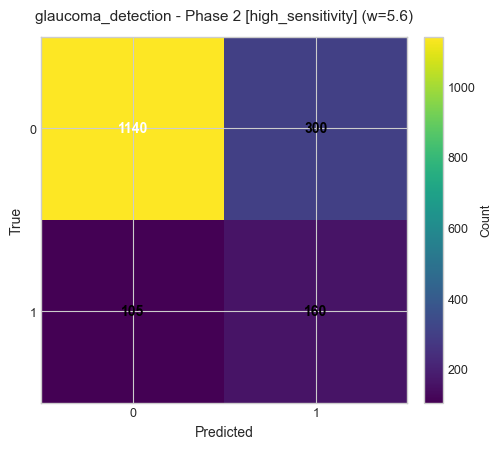

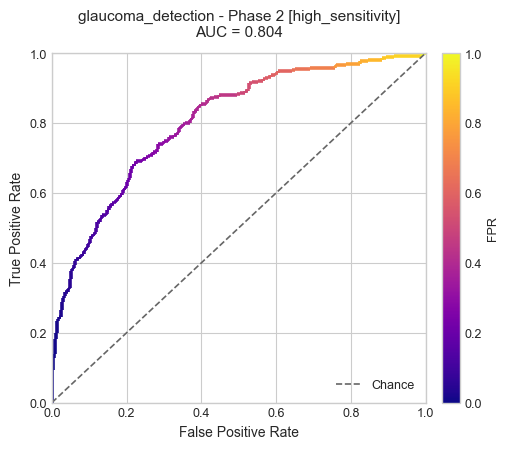


  >>> Best threshold for RETFound_mae_natureCFP: f1_optimal (F1=0.467)

PHASE 2 — Embedding 6/7: RETFound_mae_shanghai
Phase 1 baseline: F1=0.460, AUC=0.828, w=3.41
  Architecture candidates (7): [(512,), (1024,), (512, 512), (512, 256), (512, 256, 128), (1024, 512, 256), (256, 256, 256)]
  Weight search range: [1.4, 11.4] (Phase 1 best: 3.41)

  Running Phase 2 Bayesian search (30 iters, scoring=balanced_accuracy)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, tota

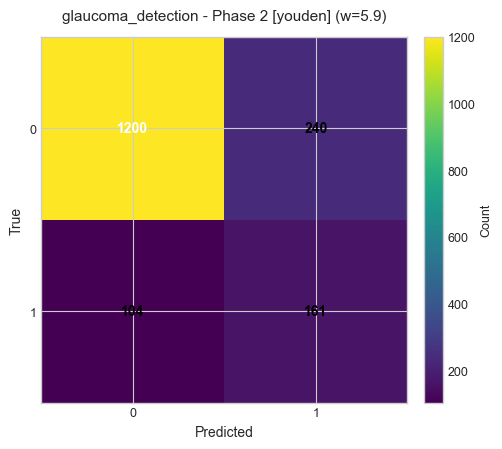

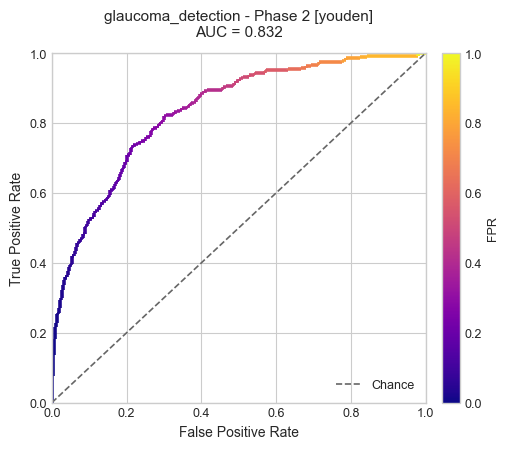


  [f1_optimal] threshold=0.686
    Accuracy=0.850, Bal.Acc=0.677, F1=0.470, Prec=0.523, Recall=0.426, AUC=0.832


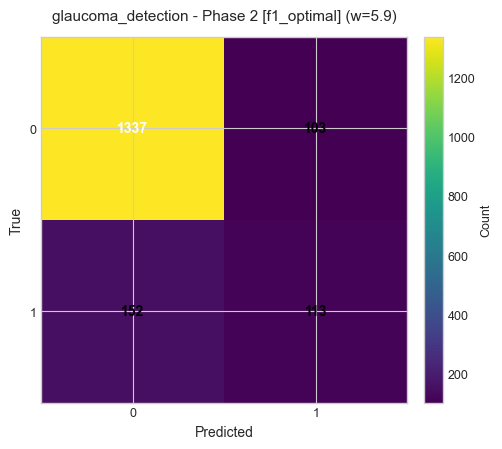

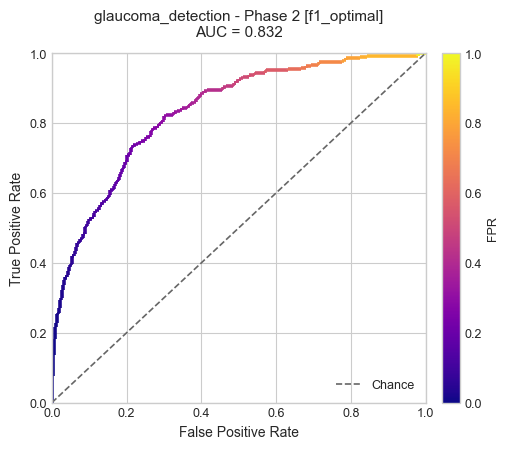


  [high_sensitivity] threshold=0.603
    Accuracy=0.828, Bal.Acc=0.712, F1=0.496, Prec=0.456, Recall=0.543, AUC=0.832


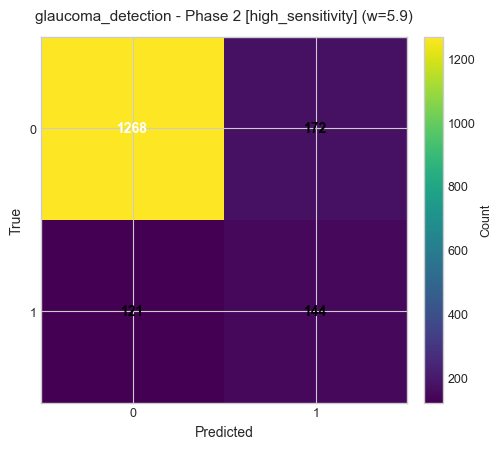

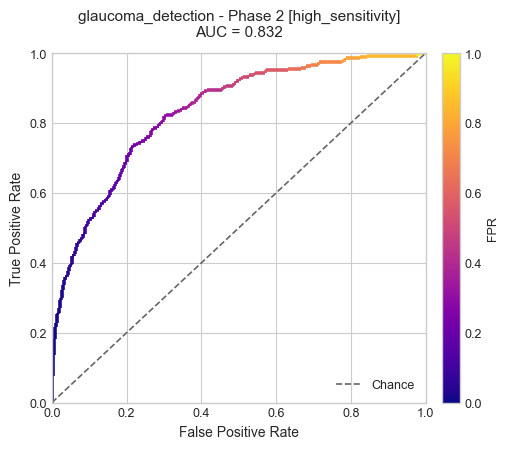


  >>> Best threshold for RETFound_mae_shanghai: high_sensitivity (F1=0.496)

PHASE 2 — Embedding 7/7: vit_base_
Phase 1 baseline: F1=0.477, AUC=0.841, w=3.16
  Architecture candidates (7): [(512,), (1024,), (512, 512), (512, 256), (512, 256, 128), (1024, 512, 256), (256, 256, 256)]
  Weight search range: [1.2, 11.2] (Phase 1 best: 3.16)

  Running Phase 2 Bayesian search (30 iters, scoring=balanced_accuracy)...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3

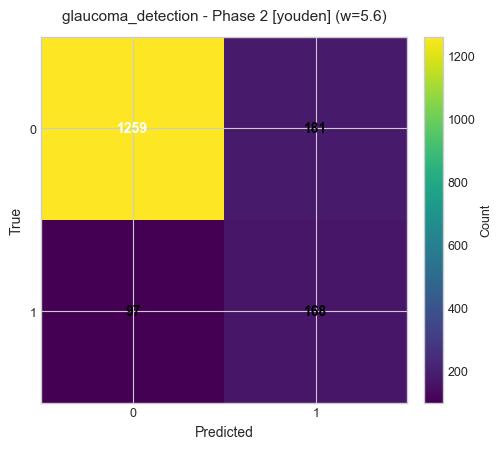

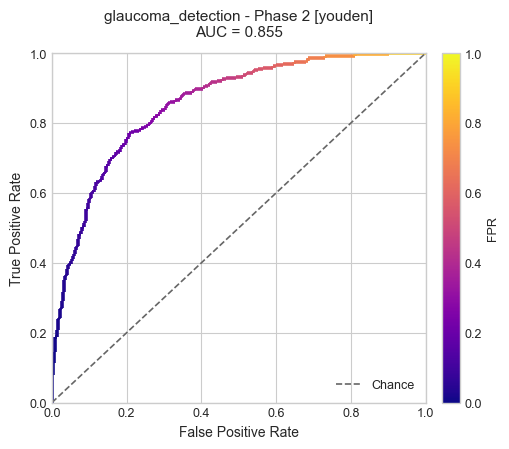


  [f1_optimal] threshold=0.701
    Accuracy=0.855, Bal.Acc=0.696, F1=0.499, Prec=0.539, Recall=0.464, AUC=0.855


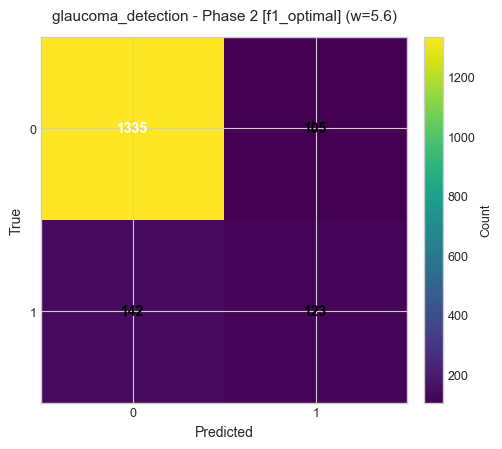

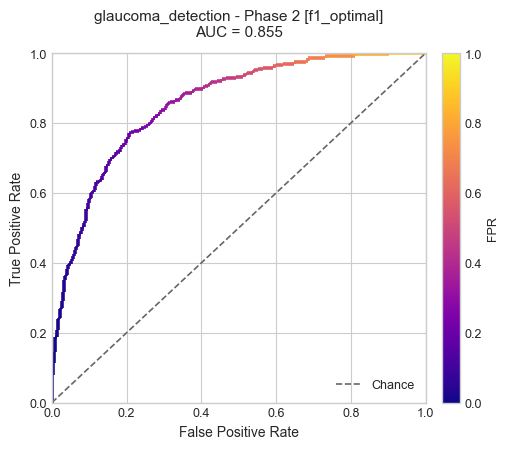


  [high_sensitivity] threshold=0.652
    Accuracy=0.852, Bal.Acc=0.727, F1=0.534, Prec=0.522, Recall=0.547, AUC=0.855


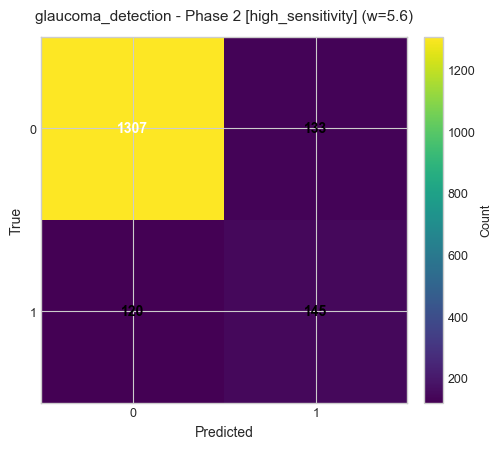

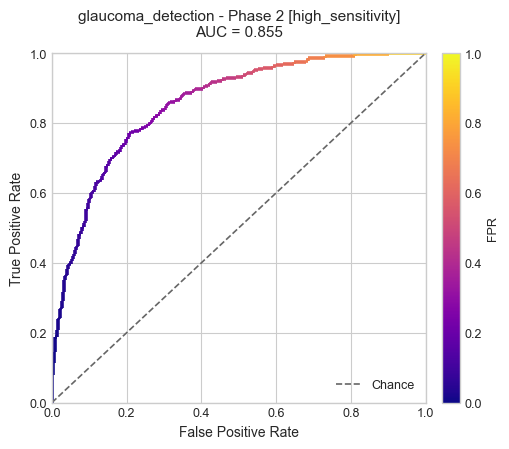


  >>> Best threshold for vit_base_: youden (F1=0.547)

Phase 2 complete!


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# PHASE 2 EXECUTION — Per-embedding aggressive refinement
# ═══════════════════════════════════════════════════════════════════════════════

PHASE2_DIR = RESULTS_DIR / "phase2_refinement"
PHASE2_DIR.mkdir(parents=True, exist_ok=True)

phase2_results = []

for emb_idx, emb_path in enumerate(embedding_files):
    emb_name = emb_path.stem
    p1_cfg = PHASE1_CONFIGS[emb_name]
    short_name = emb_name.replace("Embeddings_brset_", "")
    
    print(f"\n{'='*80}")
    print(f"PHASE 2 — Embedding {emb_idx+1}/{len(embedding_files)}: {short_name}")
    print(f"Phase 1 baseline: F1={p1_cfg['phase1_f1']:.3f}, AUC={p1_cfg['phase1_auc']:.3f}, w={p1_cfg['phase1_weight']:.2f}")
    print(f"{'='*80}")
    
    # Load dataset
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME,
        embeddings_csv_path=emb_path,
        labels_csv_path=labels_path,
    )
    
    # Apply split
    train_df, test_df = reval.apply_patient_split(ds.df, split, group_col="patient_id")
    
    task = "increased_cup_disc"
    display_task = "glaucoma_detection"
    
    train_work = train_df.dropna(subset=[task]).copy()
    test_work = test_df.dropna(subset=[task]).copy()
    
    X_train = train_work.loc[:, ds.feature_cols].to_numpy(dtype=np.float32)
    y_train = train_work[task].astype(int).to_numpy()
    X_test = test_work.loc[:, ds.feature_cols].to_numpy(dtype=np.float32)
    y_test = test_work[task].astype(int).to_numpy()
    
    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Internal validation split for threshold optimization
    from sklearn.model_selection import train_test_split
    X_train_inner, X_val_inner, y_train_inner, y_val_inner = train_test_split(
        X_train_scaled, y_train, test_size=0.15, random_state=RANDOM_SEED, stratify=y_train
    )
    
    # Phase 2 architecture candidates
    p2_archs = get_phase2_architectures(p1_cfg["arch"])
    print(f"  Architecture candidates ({len(p2_archs)}): {p2_archs}")
    
    # Aggressive weight range: expand around Phase 1 best
    p1_w = p1_cfg["phase1_weight"]
    w_low = max(1.0, p1_w - 2.0)
    w_high = min(15.0, p1_w + 8.0)
    print(f"  Weight search range: [{w_low:.1f}, {w_high:.1f}] (Phase 1 best: {p1_w:.2f})")
    
    # Phase 2 search space
    p2_search_space = {
        'hidden_layer_sizes': Integer(0, len(p2_archs) - 1, name='hidden_layer_sizes'),
        'alpha': Real(max(1e-6, p1_cfg["alpha"] / 10), min(0.1, p1_cfg["alpha"] * 10), 
                       prior='log-uniform', name='alpha'),
        'learning_rate_init': Real(max(5e-5, p1_cfg["lr"] / 3), min(2e-3, p1_cfg["lr"] * 3),
                                    prior='log-uniform', name='learning_rate_init'),
        'batch_size': Categorical([64, 128, 256], name='batch_size'),
        'pos_class_weight': Real(w_low, w_high, prior='uniform', name='pos_class_weight'),
    }
    
    # Temporarily override ARCHITECTURE_OPTIONS for the wrapper
    _orig_archs = ARCHITECTURE_OPTIONS
    ARCHITECTURE_OPTIONS = p2_archs
    
    base_mlp = MLPWrapperForBayesSearch(
        max_iter=PHASE2_MAX_EPOCHS,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=PHASE2_PATIENCE,
        random_state=RANDOM_SEED,
        warm_start=False,
    )
    
    bayes_search = BayesSearchCV(
        estimator=base_mlp,
        search_spaces=p2_search_space,
        n_iter=PHASE2_N_ITER,
        cv=BAYES_CV_FOLDS,
        n_jobs=BAYES_N_JOBS,
        scoring='balanced_accuracy',  # Force better minority class performance
        random_state=RANDOM_SEED,
        verbose=1,
    )
    
    print(f"\n  Running Phase 2 Bayesian search ({PHASE2_N_ITER} iters, scoring=balanced_accuracy)...")
    bayes_search.fit(X_train_scaled, y_train)
    
    best_model_p2 = bayes_search.best_estimator_
    best_params_p2 = bayes_search.best_params_
    best_cv_score_p2 = bayes_search.best_score_
    
    # Restore original architecture options
    ARCHITECTURE_OPTIONS = _orig_archs
    
    arch_idx_p2 = best_params_p2.get('hidden_layer_sizes', 0)
    arch_display_p2 = p2_archs[arch_idx_p2] if isinstance(arch_idx_p2, int) else arch_idx_p2
    best_weight_p2 = best_params_p2.get('pos_class_weight', 1.0)
    
    print(f"  Best CV balanced_accuracy: {best_cv_score_p2:.4f}")
    print(f"  Best architecture: {arch_display_p2}")
    print(f"  Best pos_class_weight: {best_weight_p2:.3f}")
    
    # ─── Multi-threshold evaluation ───
    val_proba = best_model_p2.predict_proba(X_val_inner)[:, 1]
    y_proba_test = best_model_p2.predict_proba(X_test_scaled)[:, 1]
    
    # Compute thresholds
    thresh_youden = find_optimal_threshold(y_val_inner, val_proba, method="youden")
    thresh_f1 = find_optimal_threshold(y_val_inner, val_proba, method="f1", grid_size=THRESHOLD_GRID_SIZE)
    
    # High-sensitivity threshold: find threshold giving recall >= 0.85 on val set
    from sklearn.metrics import recall_score as _recall_score
    best_hs_thresh, best_hs_f1 = 0.5, -1.0
    for t in np.linspace(0.01, 0.99, 201):
        y_p = (val_proba >= t).astype(int)
        rec = _recall_score(y_val_inner, y_p, zero_division=0)
        if rec >= 0.85:
            from sklearn.metrics import f1_score as _f1_score
            f1_t = _f1_score(y_val_inner, y_p, zero_division=0)
            if f1_t > best_hs_f1:
                best_hs_f1 = f1_t
                best_hs_thresh = float(t)
    
    thresholds = {
        "youden": thresh_youden,
        "f1_optimal": thresh_f1,
        "high_sensitivity": best_hs_thresh,
    }
    
    print(f"\n  Thresholds: youden={thresh_youden:.3f}, f1={thresh_f1:.3f}, high_sens={best_hs_thresh:.3f}")
    
    # Evaluate at each threshold
    test_results_base = test_work[["patient_id"]].copy()
    test_results_base["y_true"] = y_test
    test_results_base["y_proba"] = y_proba_test
    
    out_dir_p2 = PHASE2_DIR / f"{emb_idx:02d}_{short_name}"
    out_dir_p2.mkdir(parents=True, exist_ok=True)
    
    best_thresh_name = None
    best_thresh_f1 = -1.0
    
    for thresh_name, thresh_val in thresholds.items():
        y_pred_t = (y_proba_test >= thresh_val).astype(int)
        
        test_results_t = test_results_base.copy()
        test_results_t["y_pred"] = y_pred_t
        
        patient_results_t = aggregate_patient_predictions(test_results_t, group_col="patient_id")
        
        y_true_p = patient_results_t["y_true"].to_numpy()
        y_pred_p = patient_results_t["y_pred"].to_numpy()
        y_proba_p = patient_results_t["y_proba"].to_numpy()
        
        from sklearn.metrics import (f1_score, precision_score, recall_score, 
                                      balanced_accuracy_score, roc_auc_score)
        
        acc = (y_true_p == y_pred_p).mean()
        f1_val = f1_score(y_true_p, y_pred_p, zero_division=0)
        prec = precision_score(y_true_p, y_pred_p, zero_division=0)
        rec = recall_score(y_true_p, y_pred_p, zero_division=0)
        bal_acc = balanced_accuracy_score(y_true_p, y_pred_p)
        auc_val = roc_auc_score(y_true_p, y_proba_p)
        
        print(f"\n  [{thresh_name}] threshold={thresh_val:.3f}")
        print(f"    Accuracy={acc:.3f}, Bal.Acc={bal_acc:.3f}, F1={f1_val:.3f}, "
              f"Prec={prec:.3f}, Recall={rec:.3f}, AUC={auc_val:.3f}")
        
        if f1_val > best_thresh_f1:
            best_thresh_f1 = f1_val
            best_thresh_name = thresh_name
        
        # Save per-threshold results
        thresh_dir = out_dir_p2 / thresh_name
        thresh_dir.mkdir(parents=True, exist_ok=True)
        
        report_t = classification_report(y_true_p, y_pred_p, digits=3)
        (thresh_dir / "classification_report.txt").write_text(report_t, encoding="utf-8")
        
        cm_t = confusion_matrix(y_true_p, y_pred_p)
        pd.DataFrame(cm_t).to_csv(thresh_dir / "confusion_matrix.csv", index=False)
        
        fpr_t, tpr_t, _ = roc_curve(y_true_p, y_proba_p)
        
        plot_confusion_matrix(
            cm_t,
            title=f"{display_task} - Phase 2 [{thresh_name}] (w={best_weight_p2:.1f})",
            save_path=thresh_dir / "confusion_matrix.png",
            show=SHOW_PLOTS,
        )
        plot_roc_curve(
            fpr_t, tpr_t, auc_val,
            title=f"{display_task} - Phase 2 [{thresh_name}]",
            save_path=thresh_dir / "roc_curve.png",
            show=SHOW_PLOTS,
        )
        
        patient_results_t.to_csv(thresh_dir / "patient_predictions.csv", index=False)
        
        phase2_results.append({
            "embedding": short_name,
            "threshold_method": thresh_name,
            "threshold": float(thresh_val),
            "pos_class_weight": float(best_weight_p2),
            "architecture": str(arch_display_p2),
            "n_patients": len(patient_results_t),
            "accuracy": float(acc),
            "balanced_accuracy": float(bal_acc),
            "f1_score": float(f1_val),
            "precision": float(prec),
            "recall": float(rec),
            "auc": float(auc_val),
            "best_cv_balanced_acc": float(best_cv_score_p2),
            "phase1_f1": p1_cfg["phase1_f1"],
        })
    
    print(f"\n  >>> Best threshold for {short_name}: {best_thresh_name} (F1={best_thresh_f1:.3f})")
    
    # Save Phase 2 hyperparameters
    p2_hp = {k: str(v) for k, v in best_params_p2.items()}
    p2_hp["architecture_resolved"] = str(arch_display_p2)
    p2_hp["thresholds"] = {k: str(v) for k, v in thresholds.items()}
    with open(out_dir_p2 / "phase2_hyperparameters.json", "w") as f:
        json.dump(p2_hp, f, indent=2)

print(f"\n{'='*80}")
print("Phase 2 complete!")
print(f"{'='*80}")

## Phase 2 — Results Summary and Comparison

In [10]:
# Phase 2 summary
p2_df = pd.DataFrame(phase2_results)
p2_df.to_csv(PHASE2_DIR / "phase2_summary.csv", index=False)

print("Phase 2 Results — All thresholds:")
print(p2_df[["embedding", "threshold_method", "threshold", "pos_class_weight", 
             "architecture", "f1_score", "recall", "precision", "balanced_accuracy", "auc"]].to_string(index=False))

# Best F1 per embedding
print("\n" + "="*80)
print("BEST F1 per embedding (Phase 2 vs Phase 1):")
print("="*80)
for emb_name in p2_df["embedding"].unique():
    emb_rows = p2_df[p2_df["embedding"] == emb_name]
    best_row = emb_rows.loc[emb_rows["f1_score"].idxmax()]
    p1_f1 = best_row["phase1_f1"]
    p2_f1 = best_row["f1_score"]
    delta = p2_f1 - p1_f1
    status = "IMPROVED" if delta > 0.01 else ("SAME" if abs(delta) <= 0.01 else "REGRESSED")
    print(f"  {emb_name}: Phase1 F1={p1_f1:.3f} -> Phase2 F1={p2_f1:.3f} ({delta:+.3f}) [{status}]"
          f"  (thresh={best_row['threshold_method']}, w={best_row['pos_class_weight']:.2f}, "
          f"recall={best_row['recall']:.3f}, AUC={best_row['auc']:.3f})")

# Clinical viability check
print("\n" + "="*80)
print("CLINICAL VIABILITY CHECK (F1 >= 0.80 target):")
print("="*80)
for emb_name in p2_df["embedding"].unique():
    emb_rows = p2_df[p2_df["embedding"] == emb_name]
    best_f1 = emb_rows["f1_score"].max()
    best_recall = emb_rows.loc[emb_rows["f1_score"].idxmax(), "recall"]
    if best_f1 >= 0.80:
        print(f"  {emb_name}: F1={best_f1:.3f} CLINICAL GRADE")
    elif best_f1 >= 0.70:
        print(f"  {emb_name}: F1={best_f1:.3f} APPROACHING (recall={best_recall:.3f})")
    else:
        print(f"  {emb_name}: F1={best_f1:.3f} NEEDS IMPROVEMENT (recall={best_recall:.3f})")

p2_df

Phase 2 Results — All thresholds:
               embedding threshold_method  threshold  pos_class_weight architecture  f1_score   recall  precision  balanced_accuracy      auc
        convnextv2_base_           youden   0.590698          9.764730       (512,)  0.519894 0.739623   0.400818           0.768075 0.870286
        convnextv2_base_       f1_optimal   0.813600          9.764730       (512,)  0.509890 0.437736   0.610526           0.693173 0.870286
        convnextv2_base_ high_sensitivity   0.647000          9.764730       (512,)  0.531571 0.683019   0.435096           0.759912 0.870286
    dinov3_convnext_base           youden   0.551888          4.547721      (1024,)  0.469043 0.471698   0.466418           0.686196 0.836454
    dinov3_convnext_base       f1_optimal   0.676400          4.547721      (1024,)  0.407494 0.328302   0.537037           0.638109 0.836454
    dinov3_convnext_base high_sensitivity   0.509800          4.547721      (1024,)  0.476844 0.524528   0.437107 

,embedding,threshold_method,threshold,pos_class_weight,architecture,n_patients,accuracy,balanced_accuracy,f1_score,precision,recall,auc,best_cv_balanced_acc,phase1_f1
0,convnextv2_base_,youden,0.590698,9.764730,"(512,)",1705,0.787683,0.768075,0.519894,0.400818,0.739623,0.870286,0.763460,0.533333
1,convnextv2_base_,f1_optimal,0.813600,9.764730,"(512,)",1705,0.869208,0.693173,0.509890,0.610526,0.437736,0.870286,0.763460,0.533333
2,convnextv2_base_,high_sensitivity,0.647000,9.764730,"(512,)",1705,0.812903,0.759912,0.531571,0.435096,0.683019,0.870286,0.763460,0.533333
3,dinov3_convnext_base,youden,0.551888,4.547721,"(1024,)",1705,0.834018,0.686196,0.469043,0.466418,0.471698,0.836454,0.738996,0.505263
4,dinov3_convnext_base,f1_optimal,0.676400,4.547721,"(1024,)",1705,0.851613,0.638109,0.407494,0.537037,0.328302,0.836454,0.738996,0.505263
5,dinov3_convnext_base,high_sensitivity,0.509800,4.547721,"(1024,)",1705,0.821114,0.700111,0.476844,0.437107,0.524528,0.836454,0.738996,0.505263
6,dinov3_vitb16,youden,0.554239,5.208875,"(128,)",1705,0.846921,0.756958,0.559865,0.506098,0.626415,0.873975,0.773734,0.551308
7,dinov3_vitb16,f1_optimal,0.661700,5.208875,"(128,)",1705,0.866276,0.723768,0.545817,0.578059,0.516981,0.873975,0.773734,0.551308
8,dinov3_vitb16,high_sensitivity,0.573500,5.208875,"(128,)",1705,0.850440,0.746724,0.553415,0.516340,0.596226,0.873975,0.773734,0.551308
9,RETFound_dinov2_shanghai,youden,0.564602,7.965328,"(128,)",1705,0.822874,0.742721,0.523659,0.449864,0.626415,0.850333,0.734158,0.470825


## Phase 3 — Patient-Level Embedding Pooling (Classify patients, not images)

Phases 1–2 classified **images** then aggregated via majority vote. This introduces noise — one bad image prediction can flip a patient's label.

**Phase 3 strategy: pool first, classify once.**
1. For each patient, compute **mean** and **std** of all their image embeddings → concatenate to `2×D` features (e.g., 768→1536 or 1024→2048)
2. Assign patient-level label (mode of image-level labels)
3. Train MLP with BayesSearchCV directly on **patient-level features**
4. Evaluate directly — no aggregation step needed

This approach:
- Directly optimizes the metric we actually report (patient-level F1)
- Captures intra-patient variability via std features
- Reduces training set size (patients < images) but removes label noise
- Doubles feature dimensionality, giving the model richer per-patient representations

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# PHASE 3 — Patient-Level Embedding Pooling
# Pool embeddings per patient (mean + std → 2×D), then classify patients directly
# ═══════════════════════════════════════════════════════════════════════════════

import json
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              balanced_accuracy_score, roc_auc_score,
                              classification_report, confusion_matrix, roc_curve)

PHASE3_DIR = RESULTS_DIR / "phase3_patient_pooling"
PHASE3_DIR.mkdir(parents=True, exist_ok=True)

# Phase 3 search config
PHASE3_N_ITER = 30
PHASE3_MAX_EPOCHS = 300
PHASE3_PATIENCE = 25
PHASE3_CV_FOLDS = 3

# Architecture options for Phase 3 (2×D input → need capacity for wider features)
PHASE3_ARCHITECTURES = [
    (128,),
    (256,),
    (512,),
    (1024,),
    (128, 128),
    (256, 128),
    (256, 256),
    (512, 256),
    (512, 512),
    (1024, 512),
    (128, 128, 128),
    (256, 256, 128),
    (512, 256, 128),
    (1024, 512, 256),
]

PHASE3_SEARCH_SPACE = {
    'hidden_layer_sizes': Integer(0, len(PHASE3_ARCHITECTURES) - 1, name='hidden_layer_sizes'),
    'alpha': Real(1e-5, 1e-1, prior='log-uniform', name='alpha'),
    'learning_rate_init': Real(5e-5, 2e-3, prior='log-uniform', name='learning_rate_init'),
    'batch_size': Categorical([32, 64, 128, 256], name='batch_size'),
    'pos_class_weight': Real(1.0, 10.0, prior='uniform', name='pos_class_weight'),
}


def build_patient_pooled_features(df, feature_cols, group_col="patient_id", label_col="increased_cup_disc"):
    """
    Pool image-level embeddings to patient-level using mean + std concatenation.
    
    For each patient:
    - Compute mean of all image embeddings → D features
    - Compute std of all image embeddings → D features  
    - Concatenate → 2×D features
    - Label = mode of image-level labels
    
    Returns: patient_ids, X_pooled (n_patients × 2D), y_labels
    """
    patient_ids = []
    X_pooled_list = []
    y_labels = []
    
    for pid, group in df.groupby(group_col):
        features = group[feature_cols].to_numpy(dtype=np.float32)
        
        feat_mean = features.mean(axis=0)
        feat_std = features.std(axis=0) if len(features) > 1 else np.zeros_like(feat_mean)
        
        pooled = np.concatenate([feat_mean, feat_std])
        
        # Patient label = mode of image labels
        label = int(group[label_col].mode().iloc[0])
        
        patient_ids.append(pid)
        X_pooled_list.append(pooled)
        y_labels.append(label)
    
    return (
        np.array(patient_ids),
        np.array(X_pooled_list, dtype=np.float32),
        np.array(y_labels, dtype=int),
    )


print(f"Phase 3 config:")
print(f"  Pooling: mean + std concatenation → 2×D features")
print(f"  Architectures: {len(PHASE3_ARCHITECTURES)} options")
print(f"  Bayesian iterations: {PHASE3_N_ITER}, CV folds: {PHASE3_CV_FOLDS}")
print(f"  Weight search: 1.0–10.0")
print(f"  Max epochs: {PHASE3_MAX_EPOCHS}, Patience: {PHASE3_PATIENCE}")
print(f"  Batch sizes: [32, 64, 128, 256]")
print(f"  Threshold: F1-optimal (grid=201)")
print()

# ─── Run Phase 3 for all embeddings ───
phase3_results = []

for emb_idx, emb_path in enumerate(embedding_files):
    emb_name = emb_path.stem
    short_name = emb_name.replace("Embeddings_brset_", "")
    
    print(f"\n{'='*80}")
    print(f"PHASE 3 — Embedding {emb_idx+1}/{len(embedding_files)}: {short_name}")
    print(f"{'='*80}")
    
    # Load dataset
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME,
        embeddings_csv_path=emb_path,
        labels_csv_path=labels_path,
    )
    
    task = "increased_cup_disc"
    display_task = "glaucoma_detection"
    
    # Apply patient split
    train_df, test_df = reval.apply_patient_split(ds.df, split, group_col="patient_id")
    train_df = train_df.dropna(subset=[task]).copy()
    test_df = test_df.dropna(subset=[task]).copy()
    
    # ─── Build patient-level pooled features ───
    train_pids, X_train_pooled, y_train = build_patient_pooled_features(
        train_df, ds.feature_cols, group_col="patient_id", label_col=task
    )
    test_pids, X_test_pooled, y_test = build_patient_pooled_features(
        test_df, ds.feature_cols, group_col="patient_id", label_col=task
    )
    
    n_features_orig = len(ds.feature_cols)
    n_features_pooled = X_train_pooled.shape[1]
    
    classes, counts = np.unique(y_train, return_counts=True)
    pos_rate = counts[1] / counts.sum() if len(counts) > 1 else 0
    
    print(f"  Original embedding dim: {n_features_orig}")
    print(f"  Pooled feature dim: {n_features_pooled} (mean + std)")
    print(f"  Train patients: {len(y_train)} | Test patients: {len(y_test)}")
    print(f"  Class distribution (train): {dict(zip(classes.astype(int), counts))} ({pos_rate:.1%} positive)")
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_pooled)
    X_test_scaled = scaler.transform(X_test_pooled)
    
    # Internal val split for threshold optimization
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_scaled, y_train, test_size=0.15, random_state=RANDOM_SEED, stratify=y_train
    )
    
    # ─── Bayesian search on patient-level features ───
    # Temporarily swap architecture options for the wrapper
    _orig_archs = ARCHITECTURE_OPTIONS
    ARCHITECTURE_OPTIONS = PHASE3_ARCHITECTURES
    
    base_mlp = MLPWrapperForBayesSearch(
        max_iter=PHASE3_MAX_EPOCHS,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=PHASE3_PATIENCE,
        random_state=RANDOM_SEED,
        warm_start=False,
    )
    
    bayes_search = BayesSearchCV(
        estimator=base_mlp,
        search_spaces=PHASE3_SEARCH_SPACE,
        n_iter=PHASE3_N_ITER,
        cv=PHASE3_CV_FOLDS,
        n_jobs=BAYES_N_JOBS,
        scoring='f1',
        random_state=RANDOM_SEED,
        verbose=1,
    )
    
    print(f"\n  Running Phase 3 Bayesian search ({PHASE3_N_ITER} iters, scoring=f1)...")
    bayes_search.fit(X_train_scaled, y_train)
    
    best_model = bayes_search.best_estimator_
    best_params = bayes_search.best_params_
    best_cv_f1 = bayes_search.best_score_
    
    # Restore original architecture options
    ARCHITECTURE_OPTIONS = _orig_archs
    
    arch_idx = best_params.get('hidden_layer_sizes', 0)
    arch_display = PHASE3_ARCHITECTURES[arch_idx] if isinstance(arch_idx, int) else arch_idx
    best_weight = best_params.get('pos_class_weight', 1.0)
    
    print(f"  Best CV F1: {best_cv_f1:.4f}")
    print(f"  Best architecture: {arch_display}")
    print(f"  Best pos_class_weight: {best_weight:.3f}")
    print(f"  Best alpha: {best_params.get('alpha', '?')}")
    print(f"  Best lr: {best_params.get('learning_rate_init', '?')}")
    print(f"  Best batch_size: {best_params.get('batch_size', '?')}")
    
    # ─── F1-optimal threshold on internal validation set ───
    val_proba = best_model.predict_proba(X_val)[:, 1]
    opt_thresh = find_optimal_threshold(y_val, val_proba, method="f1", grid_size=201)
    print(f"  Optimal F1 threshold: {opt_thresh:.3f}")
    
    # ─── Evaluate on test patients ───
    y_proba_test = best_model.predict_proba(X_test_scaled)[:, 1]
    y_pred_test = (y_proba_test >= opt_thresh).astype(int)
    
    acc = (y_test == y_pred_test).mean()
    f1 = f1_score(y_test, y_pred_test, zero_division=0)
    prec = precision_score(y_test, y_pred_test, zero_division=0)
    rec = recall_score(y_test, y_pred_test, zero_division=0)
    bal_acc = balanced_accuracy_score(y_test, y_pred_test)
    fpr, tpr, _ = roc_curve(y_test, y_proba_test)
    auc = roc_auc_score(y_test, y_proba_test)
    
    print(f"\n  Patient-Level Metrics (DIRECT — no aggregation):")
    print(f"  Accuracy:          {acc:.3f}")
    print(f"  Balanced Accuracy: {bal_acc:.3f}")
    print(f"  F1 Score:          {f1:.3f}")
    print(f"  Precision:         {prec:.3f}")
    print(f"  Recall:            {rec:.3f}")
    print(f"  ROC AUC:           {auc:.3f}")
    
    report_text = classification_report(y_test, y_pred_test, digits=3)
    print(f"\n{report_text}")
    
    cm = confusion_matrix(y_test, y_pred_test)
    
    # ─── Save results ───
    out_dir = PHASE3_DIR / f"{emb_idx:02d}_{short_name}"
    out_dir.mkdir(parents=True, exist_ok=True)
    
    (out_dir / "classification_report.txt").write_text(report_text, encoding="utf-8")
    
    hp_save = {k: str(v) for k, v in best_params.items()}
    hp_save["architecture_resolved"] = str(arch_display)
    hp_save["optimal_threshold"] = str(opt_thresh)
    hp_save["pooling_method"] = "mean+std"
    hp_save["pooled_dim"] = str(n_features_pooled)
    with open(out_dir / "phase3_hyperparameters.json", "w") as f:
        json.dump(hp_save, f, indent=2)
    
    pd.DataFrame(cm).to_csv(out_dir / "confusion_matrix.csv", index=False)
    plot_confusion_matrix(
        cm,
        title=f"{display_task} — Phase 3 Pool (w={best_weight:.1f})",
        save_path=out_dir / "confusion_matrix.png",
        show=SHOW_PLOTS,
    )
    
    pd.DataFrame({"fpr": fpr, "tpr": tpr}).to_csv(out_dir / "roc_curve.csv", index=False)
    plot_roc_curve(
        fpr, tpr, auc,
        title=f"{display_task} — Phase 3 Pool",
        save_path=out_dir / "roc_curve.png",
        show=SHOW_PLOTS,
    )
    
    # Save patient predictions
    pred_df = pd.DataFrame({
        "patient_id": test_pids,
        "y_true": y_test,
        "y_pred": y_pred_test,
        "y_proba": y_proba_test,
    })
    pred_df.to_csv(out_dir / "patient_predictions.csv", index=False)
    
    phase3_results.append({
        "embedding": short_name,
        "pooling": "mean+std",
        "pooled_dim": n_features_pooled,
        "architecture": str(arch_display),
        "pos_class_weight": float(best_weight),
        "threshold": float(opt_thresh),
        "n_train_patients": len(y_train),
        "n_test_patients": len(y_test),
        "best_cv_f1": float(best_cv_f1),
        "accuracy": float(acc),
        "balanced_accuracy": float(bal_acc),
        "f1_score": float(f1),
        "precision": float(prec),
        "recall": float(rec),
        "auc": float(auc),
    })

print(f"\n{'='*80}")
print("Phase 3 complete!")
print(f"{'='*80}")

## Phase 3 — Results Summary and Cross-Phase Comparison

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# PHASE 3 — Summary and Cross-Phase Comparison
# ═══════════════════════════════════════════════════════════════════════════════

p3_df = pd.DataFrame(phase3_results)
p3_df.to_csv(PHASE3_DIR / "phase3_summary.csv", index=False)

print("Phase 3 Results — Patient-Level Embedding Pooling (mean+std):")
print(p3_df[["embedding", "pooled_dim", "architecture", "pos_class_weight",
             "threshold", "f1_score", "recall", "precision", "balanced_accuracy", "auc"]].to_string(index=False))

# ─── Load Phase 1 & Phase 2 results for comparison ───
p1_df = pd.read_csv(RESULTS_DIR / "summary.csv")
p2_df = pd.read_csv(PHASE2_DIR / "phase2_summary.csv")

# Best F1 per embedding from each phase
print("\n" + "="*80)
print("CROSS-PHASE COMPARISON — Best F1 per Embedding:")
print("="*80)
print(f"{'Embedding':<28} {'Phase1':>8} {'Phase2':>8} {'Phase3':>8} {'Best':>8}  {'Delta(3-1)':>10}")
print("-" * 80)

for _, row in p3_df.iterrows():
    emb = row["embedding"]
    p3_f1 = row["f1_score"]
    
    # Phase 1 match
    p1_match = p1_df[p1_df["embedding"].str.contains(emb.replace("_", ""), case=False)]
    p1_f1 = p1_match["f1_score"].max() if not p1_match.empty else 0
    
    # Phase 2 best F1 (across all thresholds)
    p2_match = p2_df[p2_df["embedding"] == emb]
    p2_f1 = p2_match["f1_score"].max() if not p2_match.empty else 0
    
    best_f1 = max(p1_f1, p2_f1, p3_f1)
    best_phase = "P1" if best_f1 == p1_f1 else ("P2" if best_f1 == p2_f1 else "P3")
    delta = p3_f1 - p1_f1
    
    print(f"  {emb:<26} {p1_f1:>7.3f}  {p2_f1:>7.3f}  {p3_f1:>7.3f}  {best_f1:>7.3f}({best_phase})  {delta:>+9.3f}")

# ─── Clinical viability check ───
print("\n" + "="*80)
print("CLINICAL VIABILITY CHECK (F1 >= 0.80 target):")
print("="*80)
for _, row in p3_df.iterrows():
    emb = row["embedding"]
    f1 = row["f1_score"]
    rec = row["recall"]
    auc = row["auc"]
    if f1 >= 0.80:
        print(f"  {emb}: F1={f1:.3f} *** CLINICAL GRADE ***  (Recall={rec:.3f}, AUC={auc:.3f})")
    elif f1 >= 0.70:
        print(f"  {emb}: F1={f1:.3f} APPROACHING  (Recall={rec:.3f}, AUC={auc:.3f})")
    elif f1 >= 0.60:
        print(f"  {emb}: F1={f1:.3f} MODERATE  (Recall={rec:.3f}, AUC={auc:.3f})")
    else:
        print(f"  {emb}: F1={f1:.3f} NEEDS MORE WORK  (Recall={rec:.3f}, AUC={auc:.3f})")

# ─── Bar chart comparison ───
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

embeddings_short = p3_df["embedding"].tolist()
x = np.arange(len(embeddings_short))
width = 0.25

# F1 comparison
ax = axes[0]
p1_f1s, p2_f1s, p3_f1s = [], [], []
for emb in embeddings_short:
    p1_m = p1_df[p1_df["embedding"].str.contains(emb.replace("_", ""), case=False)]
    p1_f1s.append(p1_m["f1_score"].max() if not p1_m.empty else 0)
    p2_m = p2_df[p2_df["embedding"] == emb]
    p2_f1s.append(p2_m["f1_score"].max() if not p2_m.empty else 0)
    p3_f1s.append(p3_df[p3_df["embedding"] == emb]["f1_score"].values[0])

bars1 = ax.bar(x - width, p1_f1s, width, label="Phase 1", color="#2E86AB", alpha=0.85)
bars2 = ax.bar(x, p2_f1s, width, label="Phase 2", color="#A23B72", alpha=0.85)
bars3 = ax.bar(x + width, p3_f1s, width, label="Phase 3 (Pool)", color="#F18F01", alpha=0.85)
ax.axhline(y=0.80, color="red", linestyle="--", linewidth=1.5, label="Clinical target (0.80)")
ax.set_xlabel("Embedding", fontsize=11)
ax.set_ylabel("F1 Score", fontsize=11)
ax.set_title("F1 Score — Phase 1 vs Phase 2 vs Phase 3", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(embeddings_short, rotation=45, ha="right", fontsize=8)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)

# AUC comparison
ax = axes[1]
p1_aucs, p3_aucs = [], []
for emb in embeddings_short:
    p1_m = p1_df[p1_df["embedding"].str.contains(emb.replace("_", ""), case=False)]
    p1_aucs.append(p1_m["auc"].max() if not p1_m.empty else 0)
    p3_aucs.append(p3_df[p3_df["embedding"] == emb]["auc"].values[0])

bars1 = ax.bar(x - width/2, p1_aucs, width, label="Phase 1", color="#2E86AB", alpha=0.85)
bars3 = ax.bar(x + width/2, p3_aucs, width, label="Phase 3 (Pool)", color="#F18F01", alpha=0.85)
ax.set_xlabel("Embedding", fontsize=11)
ax.set_ylabel("AUC", fontsize=11)
ax.set_title("ROC AUC — Phase 1 vs Phase 3", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(embeddings_short, rotation=45, ha="right", fontsize=8)
ax.legend(fontsize=9)
ax.set_ylim(0.7, 1.0)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig(PHASE3_DIR / "cross_phase_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

print(f"\nAll Phase 3 results saved to: {PHASE3_DIR}")
p3_df